# SC3021 Airbnb NYC Pricing Analysis

---

## Environment Setup & Data Loading

In [1]:
!pip install thefuzz python-Levenshtein scikit-learn xgboost

In [2]:
#All relevant imports for the notebook
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from thefuzz import process
import geopandas as gpd
import seaborn as sns

## Hypothesis/analysis goal (Ask)

**Most impactful factors affecting Airbnb pricing in New York City**

## Stakeholders

| Stakeholder | Decision / Use Case |
|---|---|
| **New Airbnb hosts** | Set competitive pricing strategy based on neighbourhood features (crime, greenery, income) |
| **Urban planners & policymakers** | Justify zoning decisions and green space investments by showing price impact |
| **Guests / consumers** | Understand neighbourhood quality signals (safety, amenity) reflected in pricing |
| **Existing hosts** | Optimize revenue by identifying underpriced or overpriced neighbourhoods relative to features |

## Hypothesis

Our hypothesis is that Airbnb nightly prices are driven by neighbourhood-level characteristics that guests use as signals of desirability and safety. Specifically, we expect that median household income reflects the overall quality and amenity density of a neighbourhood, that higher crime rates suppress demand by reducing perceived safety, and that tree density serves as a proxy for environmental quality and liveability. Distance to the CBD is also expected to matter, since proximity to central Manhattan means easier access to tourist attractions and workplaces.

Taken together, we expect neighbourhoods that score well across these factors to command higher prices, while those with weak signals on safety, income, and access will face downward pressure on what hosts can reasonably charge.

### Data Management Architecture: Three-Schema Design

This project applies the **ANSI/SPARC three-schema architecture** taught in SC3021 to organise data access across three distinct layers:

| Layer | SC3021 Definition | Implementation |
|---|---|---|
| **Internal schema** | Physical storage of data on disk | SQLite file `src/airbnb_analysis.db` |
| **Conceptual schema** | Full logical structure of the database | Raw tables: `raw_airbnb`, `raw_shooting`, `raw_arrests`, `raw_trees`, `raw_nta_population`, `raw_income_processed` |
| **External schema** | Application-specific restricted view of the conceptual schema | SQL VIEWs: `v_airbnb`, `v_shooting`, `v_arrests`, `v_trees` |

#### Justification for Each View

**`v_airbnb`** — restricts `raw_airbnb` (16 columns → 11 columns)
- **Dropped:** `id`, `name` (listing title), `host_id`, `host_name`, `last_review`
- `host_id` and `host_name` are personally identifiable information (PII) not required for neighbourhood-level aggregation. The external view enforces that the analysis layer never accesses host identity data, consistent with the lecture's principle that external schemas provide **access control** over the conceptual schema.
- `name` is unstructured free text with no analytical role, retaining it would violate the lecture's "design based on application need" principle.
- `last_review` is unused across all downstream cells; including it would introduce unnecessary **redundancy** at the schema level.

**`v_shooting`** — restricts `raw_shooting` (19 columns → 5 columns) and pushes a temporal filter to SQL
- **Dropped:** `PERP_AGE_GROUP`, `PERP_SEX`, `PERP_RACE`, `VIC_AGE_GROUP`, `VIC_SEX`, `VIC_RACE`, `STATISTICAL_MURDER_FLAG`, `PRECINCT`, `JURISDICTION_CODE`, `LOCATION_DESC`, `X_COORD_CD`, `Y_COORD_CD`, `Lon_Lat`
- Perpetrator and victim demographic attributes contain sensitive racial data that is irrelevant to neighbourhood-level incident-count analysis. The external view restricts these columns from the analysis layer entirely.
- `X_COORD_CD`, `Y_COORD_CD`, and `Lon_Lat` are **redundant** with `Latitude`/`Longitude`, retaining them violates the lecture's schema design principle of avoiding redundancy.
- `WHERE CAST(substr(OCCUR_DATE, 7, 4) AS INTEGER) BETWEEN 2015 AND 2019` pushes temporal filtering to the database engine, eliminating the need to load all rows and filter in Python.

**`v_arrests`** — restricts `raw_arrests` (19 columns → 3 columns) and pushes temporal + coordinate filters to SQL
- **Dropped:** `AGE_GROUP`, `PERP_SEX`, `PERP_RACE`, legal codes (`PD_CD`, `KY_CD`, `LAW_CODE`, `LAW_CAT_CD`), `ARREST_PRECINCT`, `JURISDICTION_CODE`, `OFNS_DESC`, `X_COORD_CD`, `Y_COORD_CD`
- `raw_arrests` contains 5 million rows. Only `ARREST_DATE`, `Latitude`, and `Longitude` are consumed by the analysis. Reducing 19 columns to 3 at the SQL level drastically cuts memory usage.
- Demographic attributes (`AGE_GROUP`, `PERP_SEX`, `PERP_RACE`) are sensitive and not needed for spatial aggregation, the view enforces **access control** by design.
- Coordinate validation (`Latitude IS NOT NULL AND Latitude != 0.0`) is pushed to SQL to remove bad records before they enter the pipeline.
- This demonstrates **logical data independence**: if `raw_arrests` gains new columns, the view and all downstream analysis code remain unchanged.

**`v_trees`** — restricts `raw_trees` (41 columns → 5 columns) and pushes a status filter to SQL
- **Dropped:** 36 unused columns including species taxonomy (`spc_latin`, `spc_common`), stump data, administrative district codes (`st_assem`, `st_senate`, `boro_ct`), and address fields.
- `WHERE status = 'Alive'` removes stumps and dead trees at query time, so only analytically relevant records enter the in-memory dataframe.
- Dropping 36 unused columns aligns with the lecture's **"design based on application need"** principle — the external schema exposes only what is necessary for the analysis task.


In [3]:
# SQLite database setup for data management
import sqlite3

db_path = Path('src') / 'airbnb_analysis.db'
sqlite_conn = sqlite3.connect(str(db_path))

print(f'Connected to database at {db_path}')

# Helper function to load data from database
def load_from_db(query):
    return pd.read_sql(query, sqlite_conn)

# Verify database tables
cursor = sqlite_conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print(f'Available tables: {[t[0] for t in tables]}')

# ── External schema: create SQL VIEWs (three-schema architecture) ──────
# Views restrict columns exposed to the analysis layer, push filters to SQL,
# and hide PII/sensitive demographics (SC3021 external schema principle).
views_ddl = [
    "DROP VIEW IF EXISTS v_airbnb",
    """CREATE VIEW v_airbnb AS
       SELECT neighbourhood_group, neighbourhood, latitude, longitude,
              room_type, price, minimum_nights, number_of_reviews,
              reviews_per_month, calculated_host_listings_count, availability_365
       FROM raw_airbnb""",
    "DROP VIEW IF EXISTS v_shooting",
    """CREATE VIEW v_shooting AS
       SELECT INCIDENT_KEY, OCCUR_DATE, BORO, Latitude, Longitude
       FROM raw_shooting
       WHERE CAST(substr(OCCUR_DATE, 7, 4) AS INTEGER) BETWEEN 2015 AND 2019""",
    "DROP VIEW IF EXISTS v_arrests",
    """CREATE VIEW v_arrests AS
       SELECT ARREST_DATE, Latitude, Longitude
       FROM raw_arrests
       WHERE CAST(substr(ARREST_DATE, 7, 4) AS INTEGER) BETWEEN 2015 AND 2019
         AND Latitude IS NOT NULL AND Longitude IS NOT NULL
         AND Latitude != 0.0 AND Longitude != 0.0""",
    "DROP VIEW IF EXISTS v_trees",
    """CREATE VIEW v_trees AS
       SELECT nta, nta_name, boroname, latitude, longitude
       FROM raw_trees
       WHERE status = 'Alive'""",
]
for ddl in views_ddl:
    cursor.execute(ddl)
sqlite_conn.commit()
print("Views created: v_airbnb, v_shooting, v_arrests, v_trees")


# Ingest MTA turnstile data into database
import pandas as pd
mta_raw = pd.read_csv(str(Path('src') / 'MTA_Subway_Turnstile_Usage_Data__2019_20260417.csv'))
mta_raw.to_sql('raw_mta', sqlite_conn, if_exists='replace', index=False)
print('Table created: raw_mta')

Connected to database at src\airbnb_analysis.db
Available tables: ['raw_airbnb', 'raw_shooting', 'raw_trees', 'raw_population', 'raw_arrests', 'raw_nta_population', 'raw_income', 'raw_income_processed']
Views created: v_airbnb, v_shooting, v_arrests, v_trees
Table created: raw_mta


In [4]:
# Use project-relative paths (works when cwd is project root; /src/ fails on Windows)
SRC = Path("src")
def _path(name):
    p = SRC / name
    if not p.exists() and "Arrests" in name and " (1)" not in name:
        alt = SRC / "NYPD_Arrests_Data__Historic_ (1).csv"
        return str(alt) if alt.exists() else str(p)
    return str(p)

airbnb_nyc_df = load_from_db("SELECT * FROM v_airbnb")
airbnb_nyc_df['reviews_per_month'] = airbnb_nyc_df['reviews_per_month'].fillna(0)  # listings with no reviews have an implicit rate of 0
nypd_shooting_df = load_from_db("SELECT * FROM v_shooting")  # 2015-2019 temporal filter applied in view
ny_tree_census_df = load_from_db("SELECT * FROM v_trees")  # status='Alive' filter applied in view
arrest_data_df = load_from_db("SELECT * FROM v_arrests")  # 2015-2019 + valid-coords filter applied in view
nta_pop_df = load_from_db("SELECT * FROM raw_nta_population")
nyc_gdf = gpd.read_file(_path("nycgeo.json"))
mta_df = load_from_db("SELECT * FROM raw_mta")
# display(ny_tree_census_df.head())
# display(nypd_shooting_df.head())
# display(airbnb_nyc_df.head())

---

## Data source identification and exploration (Prepare)

This section identifies and explores the raw data sources used throughout the analysis.

## Data Sources Overview

**Requirement analysis**: In order to estimate the price of Airbnbs, we have extracted various data points such as room type, number of reviews, availability, boroughs, along with the three factors in our hypothesis. We have selected several datasets based on New York City, and evaluated additional sources that were ultimately not used.

List of datasets considered:
- [New York City Airbnb Open Data (2019) ](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)
- [New York City Shooting Incident Dataset](https://www.kaggle.com/datasets/thaddeussegura/new-york-city-shooting-dataset)
- [NYPD Arrest Data (2006-2019) ](https://www.kaggle.com/datasets/thaddeussegura/nypd-arrest-data-20062019)
- [Median Incomes](https://data.cccnewyork.org/data/map/66/median-incomes#66/39/3/107/131/a/a)
- [Tree Census in New York City](https://www.kaggle.com/datasets/nycparks/tree-census)
- [NYC NTA Population (2010 Census)](https://data.cityofnewyork.us/City-Government/New-York-City-Population-By-Neighborhood-Tabulatio/swpk-hq0d)
- [MTA Subway Turnstile Usage Data (2019)](https://data.ny.gov/Transportation/MTA-Subway-Turnstile-Usage-Data-2019/k7j9-mn6k)

**Database schema design:** All datasets are ingested into a SQLite DBMS () and accessed through SQL VIEWs that form the external schema of a three-layer architecture. This provides logical data independence, column-level access control.

## Dataset Descriptions

### DS1: New York City Airbnb Open Data (2019)

**Description.** The NYC Airbnb Open Data dataset, downloaded on 28/01/2026, contains detailed listing activity and metrics including geographical locations, prices, and room types across New York City. Specifically, it provides neighbourhood_group (the five boroughs) and neighbourhood data. The dataset also includes the last_review date, allowing for analysis of listing popularity and guest activity. 

In [5]:
# Display the shape of the dataset to understand the number of listings and attributes.
print("Shape of Airbnb dataset:", airbnb_nyc_df.shape)

Shape of Airbnb dataset: (48895, 11)


In [6]:
# Display column names to identify relevant attributes for analysis.
print("Columns in Airbnb dataset:")
print(airbnb_nyc_df.columns.tolist())

Columns in Airbnb dataset:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [7]:
#We first take a look at the firsst 5 rows of the dataset
airbnb_nyc_df.head()


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [8]:
# Inspect the structure, data types, and non-null counts of the dataset.
airbnb_nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


**Data Format & Granularity Assessment:**

The price data is stored as numeric values (USD), while the `last_review` column uses yyyy-mm-dd format, which needs standardization when merging with other datasets that follow different date conventions such as MM/DD/YYYY in the NYPD records. Location is provided at the neighbourhood level, offering enough spatial granularity for neighbourhood-level aggregation and correlation with crime and environmental features. The `room_type` variable captures three categories (Entire home/apt, Private room, Shared room), which is useful for controlling property type effects on pricing. Coverage spans all five NYC boroughs, so no significant geographic gaps are expected.

In [9]:
# creates a clean summary table of descriptive statistics for selected numeric columns in your Airbnb dataset.
description_df = airbnb_nyc_df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']].describe().round(1)
description_df = description_df.transpose()
description_df = description_df.rename(columns={
    'count': 'Number of Listings',
    'mean': 'Average Value',
    'std': 'Standard Deviation',
    'min': 'Minimum Value',
    '25%': '25th Percentile',
    '50%': 'Median Value',
    '75%': '75th Percentile',
    'max': 'Maximum Value'
})
display(description_df)

,Number of Listings,Average Value,Standard Deviation,Minimum Value,25th Percentile,Median Value,75th Percentile,Maximum Value
price,48895.0,152.7,240.2,0.0,69.0,106.0,175.0,10000.0
minimum_nights,48895.0,7.0,20.5,1.0,1.0,3.0,5.0,1250.0
number_of_reviews,48895.0,23.3,44.6,0.0,1.0,5.0,24.0,629.0
reviews_per_month,48895.0,1.1,1.6,0.0,0.0,0.4,1.6,58.5
calculated_host_listings_count,48895.0,7.1,33.0,1.0,1.0,1.0,2.0,327.0
availability_365,48895.0,112.8,131.6,0.0,0.0,45.0,227.0,365.0


In [10]:
# Check for total number of null values for each column

empty_records = airbnb_nyc_df.isnull().sum()
empty_records[empty_records > 0]

Series([], dtype: int64)

In [11]:
# Check for number of unique values in the 'neighbourhood' column
airbnb_nyc_df['neighbourhood'].nunique()

221

**Quality considerations**

The dataset covers all five boroughs with listing-level detail on price, location, and room type, which is exactly what we need for neighbourhood-level aggregation. Some columns have missing values and neighbourhood names are inconsistent across records, so name standardization will be needed during preparation. The dataset is freely available on Kaggle, which removes any access constraints.

**Conclusions for the Airbnb dataset**

The Airbnb dataset is the core source for this project, providing the primary variable of interest alongside the spatial and listing characteristics needed to support neighbourhood-level analysis. The data quality issues identified are manageable and will be addressed during preparation.

### DS2: NYPD Shooting Incident Data (Historic)

**Description.** The Kaggle dataset, focusing on historic shooting incidents, provides a detailed log of public safety events including the exact date, time, and geographic coordinates of each occurrence from 2015-2019. This allows for the creation of "safety proximity" features that can significantly influence localized pricing models. 

In [12]:
# check the first few rows of the NYPD shooting dataset to understand its structure and content.
nypd_shooting_df.head()

,INCIDENT_KEY,OCCUR_DATE,BORO,Latitude,Longitude
0,185483181,07/21/2018,QUEENS,40.754988,-73.928849
1,187159157,09/03/2018,BROOKLYN,40.650958,-73.955869
2,183231196,05/29/2018,BROOKLYN,40.660605,-73.911335
3,177934249,04/09/2018,BROOKLYN,40.707581,-73.940679
4,166429319,06/25/2017,BRONX,40.809638,-73.890037


In [13]:
# Display column names to identify relevant attributes for analysis.
print("Columns in shooting dataset:")
print(nypd_shooting_df.columns.tolist())

Columns in shooting dataset:
['INCIDENT_KEY', 'OCCUR_DATE', 'BORO', 'Latitude', 'Longitude']


In [14]:
# Check the structure and data types of the NYPD shooting dataset
nypd_shooting_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5529 entries, 0 to 5528
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   INCIDENT_KEY  5529 non-null   int64  
 1   OCCUR_DATE    5529 non-null   object 
 2   BORO          5529 non-null   object 
 3   Latitude      5529 non-null   float64
 4   Longitude     5529 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 216.1+ KB


In [15]:
# Check the number of missing values in each column.
print("Missing values per column:")
display(nypd_shooting_df.isna().sum().sort_values(ascending=False))

Missing values per column:


INCIDENT_KEY    0
OCCUR_DATE      0
BORO            0
Latitude        0
Longitude       0
dtype: int64

In [16]:
# Analyze number of incidents per year to understand temporal distribution.
incident_years = pd.to_datetime(nypd_shooting_df['OCCUR_DATE'], errors='coerce').dt.year
display(incident_years.value_counts().sort_index())

OCCUR_DATE
2015    1434
2016    1208
2017     969
2018     951
2019     967
Name: count, dtype: int64

**Quality considerations**

The 2015-2019 scope aligns well with our Airbnb pricing window, and coverage spans all five boroughs. That said, there are a few quality issues worth noting. Shooting incidents are only recorded when reported to the NYPD, so under-reporting in certain neighbourhoods could skew the safety metrics we derive. Mapping incidents to neighbourhoods also relies on reverse-geocoding coordinates to polygon boundaries, which can introduce misclassification near borders. Reporting consistency also varies by precinct, which could artificially inflate or deflate safety rankings in some areas.

Despite these limitations, the dataset is freely available, provides precise coordinates for neighbourhood-level aggregation, and is the most comprehensive official record available for NYC in this period. To reduce data quality risks, we apply coordinate validation, filter strictly to 2015-2019, and normalize by population to control for neighbourhood size.

**Conclusion for DS2 (NYPD Shooting Incidents)**

Overall, DS2 is a strong safety indicator for this project after neighbourhood mapping and population normalization. Reporting bias and spatial matching uncertainty are acknowledged, but the dataset still provides useful signal for comparing relative neighbourhood risk patterns alongside income, greenery, and CBD proximity.

### DS3: NYPD Arrest Data (Historic)

**Description.** The Kaggle dataset, encompassing historic NYPD arrest records from 2006 to 2019, provides a comprehensive record of every arrest effected in New York City. This dataset includes highly specific geospatial coordinates and other markers such as date and time, which are vital for a long-term analysis of neighborhood safety evolution. For our Airbnb smart pricing project, this allows us to track how the safety profile of a specific neighbourhood and its market value has shifted over nearly two decades. 


In [17]:
# Check first few rows of the arrest data
arrest_data_df.head()

,ARREST_DATE,Latitude,Longitude
0,11/09/2018,40.810773,-73.952592
1,11/14/2018,40.676337,-73.865464
2,11/07/2018,40.807160,-73.965920
3,11/15/2018,40.716196,-73.997491
4,11/15/2018,40.887333,-73.847250


In [18]:
# Generate descriptive statistics for the arrest data
arrest_data_df.describe()

,Latitude,Longitude
count,1.401949e+06,1.401949e+06
mean,4.073876e+01,-7.392452e+01
std,8.141649e-02,7.536003e-02
min,4.049891e+01,-7.425494e+01
25%,4.067753e+01,-7.397490e+01
50%,4.073692e+01,-7.392733e+01
75%,4.081386e+01,-7.388237e+01
max,4.091272e+01,-7.370029e+01


In [19]:
# Check the structure and data types of the arrest dataset
arrest_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1401949 entries, 0 to 1401948
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   ARREST_DATE  1401949 non-null  object 
 1   Latitude     1401949 non-null  float64
 2   Longitude    1401949 non-null  float64
dtypes: float64(2), object(1)
memory usage: 32.1+ MB


**Quality considerations**

The dataset spans 2006-2024, so we need to filter strictly to 2015-2019 to stay aligned with the Airbnb pricing window. Coordinate quality is also uneven, with some latitude/longitude values missing or noisy, which can cause misclassification when mapping to neighbourhood polygons. It is also worth remembering that arrest rates reflect policing activity as much as actual crime levels, so neighbourhoods with heavier police presence may appear less safe than they actually are.

Despite these limitations, the dataset is detailed and well-maintained, and supports neighbourhood-level normalization when merged with population data. To reduce distortion, we map only valid coordinates, filter to the target years, aggregate to neighbourhood level, and normalize counts into per-capita rates before comparison.

### Conclusion for DS3 (NYPD Arrest Data)

DS3 is a useful complementary safety signal for this project. Enforcement and reporting effects should be kept in mind during interpretation, but the dataset is robust enough for comparative neighbourhood analysis after filtering, spatial validation, and population-based normalization.

### DS4: Median Household Income (NYC)

**Description.** The median income dataset, obtained from NYC Open Data, contains information on household income levels across different neighbourhoods in New York City, offering relevant socioeconomic context for our analysis. More precisely, it includes neighbourhood-level identifiers and corresponding median income values, which are at an appropriate level of granularity to be combined with our neighbourhood-level Airbnb and other urban datasets. 

In [20]:
# Load median income from SQLite database
median_income_df = load_from_db("SELECT * FROM raw_income_processed LIMIT 20")

# Inspect the first few rows
display(median_income_df.head(10))

,Location,Household Type,TimeFrame,DataFormat,Data,Fips
0,New York City,Families,2022,Dollars,88600.55692,3651000
1,New York City,Families with Children,2022,Dollars,80650.82217,3651000
2,New York City,Families without Children,2022,Dollars,92569.71403,3651000
3,New York City,Families without Children,2021,Dollars,89525.10054,3651000
4,New York City,Families,2021,Dollars,85063.66189,3651000
5,New York City,Families with Children,2021,Dollars,76463.55041,3651000
6,New York City,All Households,2021,Dollars,74904.80086,3651000
7,New York City,Families without Children,2019,Dollars,97558.80504,3651000
8,New York City,Families,2019,Dollars,90422.30401,3651000
9,New York City,All Households,2019,Dollars,80344.38384,3651000


In [21]:
# Inspect the row that appears to contain the actual column names
print("Potential header row:")
display(median_income_df.iloc[5])

Potential header row:


Location                   New York City
Household Type    Families with Children
TimeFrame                           2021
DataFormat                       Dollars
Data                         76463.55041
Fips                             3651000
Name: 5, dtype: object

In [22]:
# Create a temporary preview using row 5 as header, only for exploration
median_income_preview = median_income_df.copy()
median_income_preview.columns = median_income_preview.iloc[5]
median_income_preview = median_income_preview.iloc[6:].reset_index(drop=True)

# Clean preview column names for readability
median_income_preview.columns.name = None
median_income_preview.columns = [str(c).strip() for c in median_income_preview.columns]

# Display preview of the actual tabular data
display(median_income_preview.head())


,New York City,Families with Children,2021,Dollars,76463.55041,3651000
0,New York City,All Households,2021,Dollars,74904.80086,3651000
1,New York City,Families without Children,2019,Dollars,97558.80504,3651000
2,New York City,Families,2019,Dollars,90422.30401,3651000
3,New York City,All Households,2019,Dollars,80344.38384,3651000
4,New York City,Families with Children,2019,Dollars,79905.65977,3651000


In [23]:
# Check dataset structure
median_income_preview.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   New York City           14 non-null     object
 1   Families with Children  14 non-null     object
 2   2021                    14 non-null     int64 
 3   Dollars                 14 non-null     object
 4   76463.55041             14 non-null     object
 5   3651000                 14 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 804.0+ bytes


In [24]:
# Check missing values
print("Missing values per column:")
display(median_income_preview.isna().sum())

Missing values per column:


New York City             0
Families with Children    0
2021                      0
Dollars                   0
76463.55041               0
3651000                   0
dtype: int64

**Quality considerations**

The median household income dataset is a strong socioeconomic signal for pricing analysis, but it requires careful preprocessing. First, the CSV contains metadata rows and non-tabular text before the true header, so parsing with the correct row offset is necessary. Second, neighbourhood naming conventions do not perfectly match Airbnb neighbourhood labels; fuzzy matching is therefore required, which introduces potential mapping ambiguity for composite place names (for example, entries containing multiple neighbourhoods). Third, income values are reported across many years and household categories, so strict filtering to 2019 and `All Households` is needed to keep the feature temporally and conceptually aligned with the Airbnb target variable.

From a reliability standpoint, DS5 remains highly useful because it provides citywide coverage, interpretable monetary values, and a well-established proxy for neighbourhood purchasing power. To reduce bias in downstream analysis, we convert year/income fields to numeric types, remove borough/city aggregate rows when constructing neighbourhood-level features, and retain unmatched-location diagnostics so mapping quality can be inspected transparently.

**Conclusion for DS5 (Median Household Income)**

Overall, DS5 is one of the most informative datasets in this project and provides a robust neighbourhood-level demand proxy when cleaned and aligned correctly. While fuzzy matching and parsing complexity require careful handling, the resulting median-income feature is highly valuable for explaining variation in Airbnb prices across neighbourhoods.

### DS5: Tree Census (NYC 2015)

**Description.** The 2015 NYC Street Tree Census dataset, a landmark "citizen science" project known as TreesCount!, provides a comprehensive digital inventory of 666,134 street trees mapped across all five boroughs. This dataset is organized by individual tree records and can be organised by borough level. More precisely, it contains qualitative assessments of tree health and stewardship, which serve as indicators for neighborhood maintenance and resident engagement. This allows us to track how the density of trees in a specific neighbourhood can affect property prices. 

In [25]:
# Display first few rows
display(ny_tree_census_df.head())

,nta,nta_name,boroname,latitude,longitude
0,QN37,Kew Gardens Hills,Queens,40.724339,-73.805180
1,QN28,Jackson Heights,Queens,40.756626,-73.894167
2,QN76,Baisley Park,Queens,40.679777,-73.788463
3,BK31,Bay Ridge,Brooklyn,40.622743,-74.037543
4,QN12,Hammels-Arverne-Edgemere,Queens,40.596514,-73.797622


In [26]:
# check shape of dataset
print("Shape of tree census dataset:", ny_tree_census_df.shape)

Shape of tree census dataset: (652173, 5)


In [27]:
# inspect column names of the tree census dataset
print("Column names in the tree census dataset:")
print(ny_tree_census_df.columns.tolist())

Column names in the tree census dataset:
['nta', 'nta_name', 'boroname', 'latitude', 'longitude']


In [28]:
# Inspect the structure, data types, and non-null counts of the dataset.
ny_tree_census_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652173 entries, 0 to 652172
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   nta        652173 non-null  object 
 1   nta_name   652173 non-null  object 
 2   boroname   652173 non-null  object 
 3   latitude   652173 non-null  float64
 4   longitude  652173 non-null  float64
dtypes: float64(2), object(3)
memory usage: 24.9+ MB


In [29]:
# Check the number of missing values in each column to assess data completeness.
print("Missing values per column:")
display(ny_tree_census_df.isna().sum().sort_values(ascending=False))

Missing values per column:


nta          0
nta_name     0
boroname     0
latitude     0
longitude    0
dtype: int64

In [30]:
# Preview unique neighbourhood-related identifiers to check whether the dataset can be aligned at neighbourhood level.
if "nta_name" in ny_tree_census_df.columns:
    print("Number of unique NTA names:", ny_tree_census_df["nta_name"].nunique())
    display(ny_tree_census_df["nta_name"].dropna().unique()[:20])
else:
    print("Column 'nta_name' not found in dataset.")

Number of unique NTA names: 188


array(['Kew Gardens Hills', 'Jackson Heights', 'Baisley Park',
       'Bay Ridge', 'Hammels-Arverne-Edgemere', 'Hamilton Heights',
       'East New York (Pennsylvania Ave)', 'Borough Park', 'Woodhaven',
       'Hunts Point', 'Richmond Hill', 'Great Kills',
       'Hudson Yards-Chelsea-Flatiron-Union Square',
       "Annadale-Huguenot-Prince's Bay-Eltingville",
       'Springfield Gardens North',
       'Georgetown-Marine Park-Bergen Beach-Mill Basin',
       'Stapleton-Rosebank',
       'DUMBO-Vinegar Hill-Downtown Brooklyn-Boerum Hill', 'Ocean Hill',
       'Cambria Heights'], dtype=object)

**Quality considerations**

The NYC Tree Census dataset is high-volume and spatially rich, but several quality checks are necessary before using it as a neighbourhood-level pricing feature. First, the tree records are from 2015, while Airbnb pricing is from 2019, so this feature should be interpreted as a relatively stable environmental proxy rather than a perfectly time-aligned measure. Second, neighbourhood alignment depends on mapping `nta_name` values to Airbnb neighbourhood labels via fuzzy matching; ambiguous name variants and boundary differences can introduce classification noise. Third, raw tree counts are sensitive to neighbourhood size, so normalization by land area (`trees_per_sq_mile`) is essential for fair cross-neighbourhood comparison.

**Conclusion**

From a data reliability perspective, DS6 is still useful because it has extensive citywide coverage and objective physical observations (tree locations and counts). To reduce bias in downstream analysis, we retain only mapped neighbourhood records, merge with projected polygon area in square miles, and avoid divide-by-zero or invalid area cases when constructing density metrics.

### DS6: NYC Neighbourhood Tabulation Area (NTA) Population

**Description.** The NYC NTA Population dataset, published by the NYC Department of City Planning and sourced from the US decennial census, provides population counts for all 195 Neighbourhood Tabulation Areas across two census years (2000 and 2010). NTAs are standardised geographic units designed by the city to produce statistically reliable estimates at sub-borough granularity, with populations typically ranging from 15,000 to 130,000 residents. Each record includes a borough label, census year, FIPS county code, NTA code, NTA name, and population count. In this analysis, the 2010 figures are fuzzy-matched to Airbnb neighbourhood names and used as the population denominator for computing per-capita shooting and arrest density rates in Steps 4 and 6.

In [31]:
# Preview NTA population data
print("Shape:", nta_pop_df.shape)
print("Years available:", sorted(nta_pop_df["Year"].unique().tolist()))
print("Unique NTAs:", nta_pop_df["NTA Name"].nunique())
display(nta_pop_df[nta_pop_df["Year"] == 2010].describe())
display(nta_pop_df.head())

Shape: (390, 6)
Years available: [2000, 2010]
Unique NTAs: 195


,Year,FIPS County Code,Population
count,195.0,195.000000,195.000000
mean,2010.0,54.712821,41923.758974
std,0.0,28.320689,22282.970575
min,2010.0,5.000000,0.000000
25%,2010.0,47.000000,26172.000000
50%,2010.0,61.000000,36891.000000
75%,2010.0,81.000000,53896.000000
max,2010.0,85.000000,132378.000000


,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,Bronx,2000,5,BX01,Claremont-Bathgate,28149
1,Bronx,2000,5,BX03,Eastchester-Edenwald-Baychester,35422
2,Bronx,2000,5,BX05,Bedford Park-Fordham North,55329
3,Bronx,2000,5,BX06,Belmont,25967
4,Bronx,2000,5,BX07,Bronxdale,34309


**Quality considerations**

The NTA population dataset is complete with no missing values across all 195 NTAs for both census years, making it reliable for normalisation purposes. However, two limitations apply. First, only 2000 and 2010 census figures are available. The 2010 data used here is nine years older than the 2019 Airbnb pricing data, meaning neighbourhoods that experienced significant population change in that period may have slightly distorted per-capita crime rates. Second, NTA boundaries do not perfectly match Airbnb neighbourhood labels, so fuzzy matching is used to align them; this introduces a small risk of incorrect linkages for ambiguously named areas.

### DS7: MTA Subway Turnstile Usage Data (2019)

**Description.** The MTA Subway Turnstile Usage dataset, contains average daily subway entries and exits for each station across the New York City subway network in 2019. It covers 379 stations and provides a direct measure of transit ridership, which could serve as a proxy for neighbourhood accessibility and footfall. Since transit access is a plausible driver of Airbnb demand, we explored this dataset as a potential feature to complement CBD distance in our pricing model.

In [32]:
# Preview the first few rows
mta_df.head()

,Station,avg_entries,avg_exits
0,103 ST,"20,510,260.25613103407","32,190,632.27695566561"
1,103 ST-CORONA,"8,017,529.65034642032","8,039,115.83520656916"
2,104 ST,"449,180,391.13577497","320,451,650.16209076"
3,110 ST,"6,356,580.41214323567","6,141,198.97388144447"
4,111 ST,"8,347,616.68410566232","4,301,234.83675043383"


In [33]:
# Check shape and column names
print("Shape:", mta_df.shape)
print("Columns:", mta_df.columns.tolist())

Shape: (379, 3)
Columns: ['Station', 'avg_entries', 'avg_exits']


**Data Format & Granularity Assessment:**

The dataset is structured at the station level, with one row per subway station and columns for station name, average entries, and average exits. The station names use an abbreviated naming convention drawn from MTA signage, such as '103 ST', '14 ST-UNION SQ', and '138/GRAND CONC', which does not correspond to any standard geographic boundary used in the other datasets. Notably, there are no latitude/longitude coordinates, no borough labels, and no neighbourhood identifiers in the dataset, meaning spatial joining to Airbnb neighbourhood boundaries is not straightforward.

In [34]:
# Explore station naming conventions
print("Total stations:", mta_df["Station"].nunique())

# Show stations with ambiguous names
ambiguous = mta_df[mta_df["Station"].str.contains("14 ST|103 ST|116 ST", regex=True)]
print("Example of ambiguous station names:")
print(ambiguous["Station"].tolist())

# Check for any coordinate or location columns
print("Columns available:", mta_df.columns.tolist())
print("Missing values:", mta_df.isnull().sum().to_dict())

Total stations: 379
Example of ambiguous station names:
['103 ST', '103 ST-CORONA', '116 ST', '116 ST-COLUMBIA', '14 ST', '14 ST-UNION SQ']
Columns available: ['Station', 'avg_entries', 'avg_exits']
Missing values: {'Station': 0, 'avg_entries': 0, 'avg_exits': 0}


In [35]:
# Attempt fuzzy matching between MTA station names and Airbnb neighbourhood names
airbnb_neighbourhoods = airbnb_nyc_df["neighbourhood"].dropna().unique().tolist()

from thefuzz import process

match_results = []
for station in mta_df["Station"]:
    match, score = process.extractOne(station, airbnb_neighbourhoods)
    match_results.append({"station": station, "best_match": match, "score": score})

match_df = pd.DataFrame(match_results)

# Show how many stations match above a reasonable threshold
threshold = 75
good_matches = match_df[match_df["score"] >= threshold]
print(f"Stations with a match score >= {threshold}: {len(good_matches)} out of {len(mta_df)}")
print("Sample matches:")
display(match_df.head(15))

Stations with a match score >= 75: 165 out of 379
Sample matches:


,station,best_match,score
0,103 ST,St. George,86
1,103 ST-CORONA,Corona,90
2,104 ST,St. George,86
3,110 ST,St. George,86
4,111 ST,St. George,86
5,116 ST,St. George,86
6,116 ST-COLUMBIA,Columbia St,95
7,121 ST,St. George,86
8,125 ST,St. George,86
9,135 ST,St. George,86


**Quality considerations**

The core issue with this dataset is that it provides no geographic reference beyond station names. Without coordinates or neighbourhood labels, the only way to join it to our analysis table is through string matching between station names and Airbnb neighbourhood names, which produces unreliable results as shown above. Station names like '14 ST' are genuinely ambiguous, referring to multiple physical locations across different lines and boroughs, and the abbreviated MTA naming convention has no consistent relationship to neighbourhood boundaries.

Even if matching were feasible, aggregating station-level ridership to neighbourhood level would require decisions about which stations to assign to which neighbourhoods, introducing arbitrary choices that could significantly affect the resulting feature. The dataset also only contains entries and exits with no breakdown by time of day, direction, or line, limiting the granularity of any transit access signal we could derive.

**Conclusion for DS7 (MTA Subway Turnstile Usage Data)**

Despite transit access being a plausible pricing factor, this dataset cannot be reliably integrated into our neighbourhood-level analysis. The absence of coordinates or neighbourhood identifiers makes spatial joining unfeasible, and fuzzy name matching produces too many ambiguous or incorrect linkages to be trusted as a feature. We therefore do not include this dataset in the analysis.

---

## Data preparation (Process)

This section covers all data cleaning, transformation, feature engineering, and dataset integration steps required before analysis.

As part of data preparation, we implement a series of transformation, integration, and profiling tasks to construct a unified neighbourhood-level dataset for analysis. Relying on the data obtained from the Airbnb listings dataset and multiple NYC Open Data sources, we first retain only the attributes relevant to our study and standardize them into a consistent format. Since the raw datasets are recorded at different granularities, we map coordinate-based records to NYC neighbourhoods using official neighbourhood boundary polygons and align all datasets at the neighbourhood level. We then clean invalid and incomplete records, normalize selected variables where appropriate, and compute derived indicators such as Airbnb price per room, housing price per residential unit, and incident rates per population.

Next, we integrate the prepared datasets into a single analytical table containing Airbnb, housing, crime, and environmental indicators for each neighbourhood. To improve comparability across datasets, we further derive density-based and rate-based attributes, such as shootings per population and tree density by neighbourhood area. Profiling the resulting variables allows us to inspect missing values, identify possible inconsistencies, and verify that the transformed attributes exhibit reasonable distributions. Finally, we persistently store the prepared dataset for subsequent exploratory analysis and modeling.

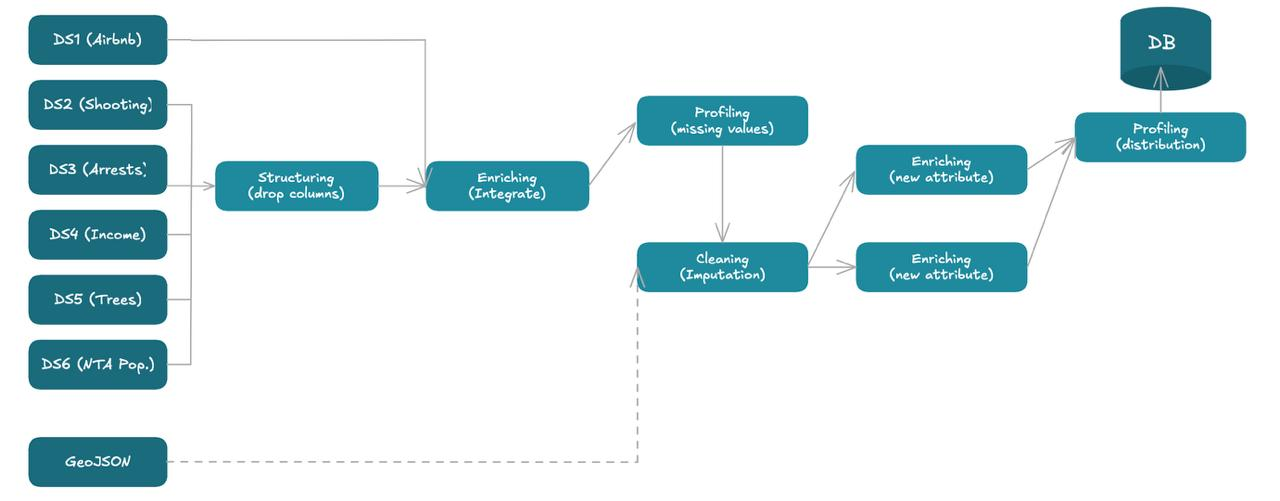

## Data Cleaning & Feature Engineering

### Step 1: Reusable Spatial Mapping Utilities

To make downstream integration consistent, we first define helper functions for neighbourhood mapping. The key utility maps latitude/longitude points to NYC neighbourhood polygons and then harmonizes names to Airbnb neighbourhood labels using fuzzy matching. This allows us to reuse the same logic across shootings, arrests, and environmental datasets.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Generate a Python function that performs a spatial join between a dataframe containing latitude and longitude columns and a GeoJSON boundary file to assign each row a NYC neighbourhood name</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 1</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 1</td></tr>
</table>

In [36]:
def map_coordinates_to_neighbourhood(df):

    temp_df = df.copy()

    # Detect latitude / longitude columns case-insensitively.
    lower_to_original = {c.lower(): c for c in temp_df.columns}
    lat_col = lower_to_original.get('latitude')
    lon_col = lower_to_original.get('longitude')

    if lat_col is None or lon_col is None:
        raise ValueError("Input dataframe must contain latitude/longitude columns.")

    # Coerce to numeric and keep only valid coordinate rows for spatial join.
    temp_df[lat_col] = pd.to_numeric(temp_df[lat_col], errors='coerce')
    temp_df[lon_col] = pd.to_numeric(temp_df[lon_col], errors='coerce')
    valid_mask = (
        temp_df[lat_col].between(-90, 90)
        & temp_df[lon_col].between(-180, 180)
        & temp_df[lat_col].notna()
        & temp_df[lon_col].notna()
    )

    valid_df = temp_df.loc[valid_mask].copy()

    # Initialize neighbourhood to preserve original row count/order.
    temp_df['neighbourhood'] = pd.NA
    if valid_df.empty:
        return temp_df

    gdf = gpd.GeoDataFrame(
        valid_df,
        geometry=gpd.points_from_xy(valid_df[lon_col], valid_df[lat_col]),
        crs='EPSG:4326',
    )

    nyc_gdf_local = nyc_gdf[['geometry', 'NTAName']].copy()
    if nyc_gdf_local.crs is None:
        nyc_gdf_local = nyc_gdf_local.set_crs('EPSG:4326')
    elif nyc_gdf_local.crs.to_string() != 'EPSG:4326':
        nyc_gdf_local = nyc_gdf_local.to_crs('EPSG:4326')

    joined = gpd.sjoin(gdf, nyc_gdf_local, how='left', predicate='within')

    mapped = fuzzy_map_neighbourhood(joined, 'NTAName')
    temp_df.loc[mapped.index, 'neighbourhood'] = mapped['neighbourhood']

    return temp_df


def fuzzy_map_neighbourhood(df, target_column):

    temp_df = df.copy()
    airbnb_unique_hoods = airbnb_nyc_df['neighbourhood'].dropna().unique().tolist()

    source_hoods = temp_df[target_column].dropna().unique().tolist()

    fuzz_map = {}
    for hood in source_hoods:
        match, score = process.extractOne(hood, airbnb_unique_hoods)
        fuzz_map[hood] = match if score >= 75 else None

    temp_df['neighbourhood'] = temp_df[target_column].map(fuzz_map)
    return temp_df

### Step 2: Airbnb Neighbourhood Cleaning and CBD Distance Features

We standardize Airbnb neighbourhood naming and derive location features by computing each listing’s distance to two NYC CBD anchors (Times Square and Lower Manhattan).

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Generate Python functions to clean Airbnb neighbourhood name strings, compute the distance in kilometres from each listing to the nearest NYC central business district point, and produce a neighbourhood-level summary table of minimum CBD distance</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 2</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 2</td></tr>
</table>

In [37]:
# cleans the neighbourhood names
# computes each listing’s distance to the NYC CBD area
# creates a neighbourhood-level CBD distance table
def clean_neighbourhood_keep_coop(value):
    if pd.isna(value):
        return pd.NA
    s = str(value).strip()
    primary = s.split(',')[0].strip()
    if primary.lower() == 'co-op city':
        return 'Co-op City'
    return primary.split('-')[0].strip()

# Distance utility reused in downstream cells.
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dlon / 2.0) ** 2)
    a = np.clip(a, 0, 1)
    return 2 * R * np.arcsin(np.sqrt(a))

# Keep all neighbourhoods, including Co-op City.
airbnb_nyc_df['neighbourhood'] = airbnb_nyc_df['neighbourhood'].apply(clean_neighbourhood_keep_coop)
average_price_by_neighbourhood = airbnb_nyc_df.groupby('neighbourhood')['price'].mean().reset_index()

# Compute CBD distance for each listing only (no correlation in this cell).
airbnb_nyc_df['latitude'] = pd.to_numeric(airbnb_nyc_df['latitude'], errors='coerce')
airbnb_nyc_df['longitude'] = pd.to_numeric(airbnb_nyc_df['longitude'], errors='coerce')

times_sq = (40.7580, -73.9855)
lower_manhattan = (40.7075, -74.0113)

airbnb_nyc_df['dist_to_times_sq_km'] = haversine_km(
    airbnb_nyc_df['latitude'].to_numpy(),
    airbnb_nyc_df['longitude'].to_numpy(),
    times_sq[0],
    times_sq[1],
)
airbnb_nyc_df['dist_to_lower_manhattan_km'] = haversine_km(
    airbnb_nyc_df['latitude'].to_numpy(),
    airbnb_nyc_df['longitude'].to_numpy(),
    lower_manhattan[0],
    lower_manhattan[1],
)
airbnb_nyc_df['dist_to_cbd_min_km'] = airbnb_nyc_df[['dist_to_times_sq_km', 'dist_to_lower_manhattan_km']].min(axis=1)

# Keep neighbourhood-level CBD table available for neighbourhood correlation cell.
cbd_distance_by_neighbourhood = (
    airbnb_nyc_df[['neighbourhood', 'dist_to_cbd_min_km']]
    .dropna(subset=['neighbourhood', 'dist_to_cbd_min_km'])
    .groupby('neighbourhood', as_index=False)['dist_to_cbd_min_km']
    .mean()
)

print('Computed dist_to_cbd_min_km for Airbnb listings.')
print(f'Listings with CBD distance: {airbnb_nyc_df["dist_to_cbd_min_km"].notna().sum()}')
display(airbnb_nyc_df[['neighbourhood', 'price', 'dist_to_cbd_min_km']].head(20))

Computed dist_to_cbd_min_km for Airbnb listings.
Listings with CBD distance: 48895


,neighbourhood,price,dist_to_cbd_min_km
0,Kensington,149,7.436667
1,Midtown,225,0.508366
2,Harlem,150,6.757240
3,Clinton Hill,89,5.006161
4,East Harlem,80,5.701496
5,Murray Hill,200,1.449704
6,Bedford,60,5.198369
7,Hell's Kitchen,79,0.767636
8,Upper West Side,79,5.105387
9,Chinatown,150,1.883729


### Step 3: Shooting Data Time Filtering and Baseline Counts

We first restrict shooting records to 2015-2019 and compute neighbourhood incident counts. This creates a baseline crime volume table before population normalization.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Filter the NYPD shooting incidents dataset to records from 2015 to 2019, map each shooting's GPS coordinates to a neighbourhood using the spatial mapping function, and count total shooting incidents per neighbourhood</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 3</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 3</td></tr>
</table>

In [38]:
# Shooting records already filtered to 2015-2019 by v_shooting view
shooting_2015_2019 = nypd_shooting_df.copy()
shooting_2015_2019['OCCUR_DATE'] = pd.to_datetime(
    shooting_2015_2019['OCCUR_DATE'],
    errors='coerce'
 )

# Ensure neighbourhood exists before counting incidents
if 'neighbourhood' not in shooting_2015_2019.columns:
    shooting_2015_2019 = map_coordinates_to_neighbourhood(shooting_2015_2019)

# Calculate value counts for each matched neighborhood
incident_counts = shooting_2015_2019['neighbourhood'].value_counts().reset_index()
incident_counts.columns = ['neighbourhood', 'incident_count']

# Display the top 20 neighborhoods by incident count
display(incident_counts.head(20))

,neighbourhood,incident_count
0,Harlem,400
1,East New York,270
2,Crown Heights,255
3,Brownsville,191
4,Mott Haven,171
5,Stuyvesant Town,160
6,Bedford,160
7,Tremont,150
8,Flatbush,139
9,West Village,130


### Step 4: Airbnb-to-Census Population Mapping

To enable rate-based indicators, we fuzzy-match Airbnb neighbourhood names to official NTA population records (2010 census) and build a reusable neighbourhood population lookup.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Use fuzzy matching with a 75 percent threshold to map unique Airbnb neighbourhood names to NTA population reference names from the NTA population dataset so that population figures can be joined to Airbnb listings for rate-based indicators</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 4</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 4</td></tr>
</table>

In [39]:
# 1. Prepare unique Airbnb neighborhoods (including Co-op City)
airbnb_unique_hoods = airbnb_nyc_df['neighbourhood'].dropna().unique().tolist()

# 2. Extract NTA population reference (Year 2010)
nta_2010 = nta_pop_df[nta_pop_df['Year'] == 2010].groupby('NTA Name')['Population'].sum().reset_index()
nta_names = nta_2010['NTA Name'].tolist()

# 3. Perform Fuzzy Matching (75% threshold)
mapping_results = []
for hood in airbnb_unique_hoods:
    match, score = process.extractOne(hood, nta_names)
    pop_val = nta_2010.loc[nta_2010['NTA Name'] == match, 'Population'].values[0] if score >= 75 else None
    mapping_results.append({'Airbnb Neighbourhood': hood, 'Population (2010 Census)': pop_val})

# 4. Create and display the final mapping table
airbnb_pop_map_df = pd.DataFrame(mapping_results).sort_values('Airbnb Neighbourhood')

print(f'Created population mapping for {len(airbnb_pop_map_df)} neighborhoods.')
display(airbnb_pop_map_df.head(20))

Created population mapping for 220 neighborhoods.


,Airbnb Neighbourhood,Population (2010 Census)
69,Allerton,28903.0
214,Arden Heights,25238.0
86,Arrochar,16079.0
106,Arverne,36885.0
56,Astoria,78793.0
197,Bath Beach,29931.0
101,Battery Park City,39699.0
90,Bay Ridge,79371.0
140,Bay Terrace,21751.0
187,Baychester,34517.0


### Step 5: Apply Spatial Join to Shooting Records

We assign a neighbourhood label to each shooting record using latitude/longitude and NYC neighbourhood polygons.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Apply the spatial coordinate-to-neighbourhood mapping function to the full NYPD shooting incidents dataframe to assign a neighbourhood label to every shooting record based on its GPS coordinates</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 5</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 5</td></tr>
</table>

In [40]:
# Map NYPD shooting coordinates to neighbourhoods
nypd_shooting_df = map_coordinates_to_neighbourhood(nypd_shooting_df)

### Step 6: Shooting Density per Population

After spatial mapping, we merge shooting counts with census population and calculate `shootings_per_10000_2015_2019` to normalize neighbourhood comparisons.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Merge shooting incident counts per neighbourhood with the fuzzy-mapped NTA population figures and calculate shootings per 10,000 residents for the 2015 to 2019 period, guarding against division by zero</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 6</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 6</td></tr>
</table>

In [41]:
# Merge incident counts with the population mapping
# airbnb_pop_map_df contains the population per Airbnb neighbourhood
# incident_counts contains total shootings per airbnb_matched_neighbourhood

neighbourhood_stats = incident_counts.merge(
    airbnb_pop_map_df,
    left_on='neighbourhood',
    right_on='Airbnb Neighbourhood',
    how='inner'
)

# 2. Calculate shootings per 10,000 people for 2015-2019
# We ensure we don't divide by zero and only include valid population data
neighbourhood_stats = neighbourhood_stats[neighbourhood_stats['Population (2010 Census)'] > 0]

neighbourhood_stats['shootings_per_10000_2015_2019'] = (
    neighbourhood_stats['incident_count'] / neighbourhood_stats['Population (2010 Census)']
) * 10000

# 3. Sort by the new metric
neighbourhood_stats = neighbourhood_stats.sort_values(by='shootings_per_10000_2015_2019', ascending=False)

# Display the top results
print("Neighborhoods with the highest shooting density (per 10,000 residents) from 2015 to 2019:")
display(neighbourhood_stats[['neighbourhood', 'incident_count', 'Population (2010 Census)', 'shootings_per_10000_2015_2019']].head(20))

Neighborhoods with the highest shooting density (per 10,000 residents) from 2015 to 2019:


,neighbourhood,incident_count,Population (2010 Census),shootings_per_10000_2015_2019
5,Stuyvesant Town,160,21049.0,76.013112
0,Harlem,400,75282.0,53.133551
16,Prospect,91,19849.0,45.846138
4,Mott Haven,171,39214.0,43.606875
18,Lighthouse Hill,80,22887.0,34.954341
7,Tremont,150,43423.0,34.543905
3,Brownsville,191,58300.0,32.761578
1,East New York,270,91958.0,29.361230
2,Crown Heights,255,103169.0,24.716727
25,Springfield Gardens,59,25409.0,23.220119


### Step 7: Arrest Density Normalization (2015-2019)

We convert annual arrests-per-10,000 into a 2015-2019 mean arrests-per-1,000 indicator for each neighbourhood. This creates a stable safety-related feature for downstream analysis.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Map NYPD arrest records to neighbourhoods using GPS coordinates, extract the year from each arrest date, and compute the mean annual arrest rate per 1,000 residents across 2015 to 2019 using the fuzzy-matched population figures</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 7</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 7</td></tr>
</table>

In [42]:
# Arrest density per 10,000 residents, by year
# NYPD arrests dataset uses these coordinate columns: 'Latitude' and 'Longitude'.
# Column selection handled by v_arrests view (returns ARREST_DATE, Latitude, Longitude only)
arrest_input = arrest_data_df.copy()

print('Mapping arrests to neighbourhood using Latitude/Longitude...')
arrest_mapped = map_coordinates_to_neighbourhood(arrest_input)
arrest_mapped = arrest_mapped.dropna(subset=['neighbourhood']).copy()

# 1. Parse ARREST_DATE to extract year
arrest_mapped['year'] = pd.to_datetime(
    arrest_mapped['ARREST_DATE'],
    format='%m/%d/%Y',
    errors='coerce'
).dt.year
arrest_mapped = arrest_mapped.dropna(subset=['year'])
arrest_mapped['year'] = arrest_mapped['year'].astype(int)

# 2. Count arrests per neighbourhood per year
arrest_counts_by_year = (
    arrest_mapped.groupby(['neighbourhood', 'year'])
    .size()
    .reset_index(name='arrest_count')
)

# 3. Merge with population (2010 Census) for density calculation
arrest_density_by_year = arrest_counts_by_year.merge(
    airbnb_pop_map_df,
    left_on='neighbourhood',
    right_on='Airbnb Neighbourhood',
    how='inner'
)
arrest_density_by_year = arrest_density_by_year[arrest_density_by_year['Population (2010 Census)'] > 0]
arrest_density_by_year['arrests_per_10000'] = (
    arrest_density_by_year['arrest_count'] / arrest_density_by_year['Population (2010 Census)']
 ) * 10000

print("Generated arrest_density_by_year.")

arrest_density_2015_2019 = arrest_density_by_year[
    arrest_density_by_year['year'].between(2015, 2019)
].copy()

arrest_density_2015_2019['arrests_per_1000'] = (
    arrest_density_2015_2019['arrests_per_10000'] / 10
)

mean_arrests_per_1000 = (
    arrest_density_2015_2019
    .groupby('neighbourhood', as_index=False)['arrests_per_1000']
    .mean()
    .rename(columns={'arrests_per_1000': 'mean_arrests_per_1000'})
    .sort_values('mean_arrests_per_1000', ascending=False)
)

print('Mean arrests per 1,000 residents (2015-2019):')
display(mean_arrests_per_1000.head(20))

Mapping arrests to neighbourhood using Latitude/Longitude...


Generated arrest_density_by_year.
Mean arrests per 1,000 residents (2015-2019):


,neighbourhood,mean_arrests_per_1000
88,Midtown,348.250087
67,Harlem,229.295183
92,Mott Haven,216.050390
116,Springfield Gardens,147.798024
71,Hunts Point,144.339068
32,Clinton Hill,142.301170
120,Stuyvesant Town,135.417359
74,Jamaica,122.457257
103,Prospect,122.051489
17,Boerum Hill,120.568198


### Step 8: Tree Census Neighbourhood Mapping

We map tree-census neighbourhood identifiers (`nta_name`) to Airbnb neighbourhood labels using fuzzy matching and aggregate total trees per neighbourhood.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Apply fuzzy neighbourhood name matching to align the NYC tree census NTA name column with Airbnb neighbourhood names and aggregate total tree counts per matched neighbourhood</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 8</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 8</td></tr>
</table>

In [43]:
# 1. Apply fuzzy mapping to align tree census 'nta_name' with Airbnb neighborhoods
# Note: 'nta_name' is the target column in ny_tree_census_df
tree_census_mapped = fuzzy_map_neighbourhood(ny_tree_census_df, 'nta_name')

# 2. Keep all matched neighbourhood records that meet the 75% threshold
tree_census_mapped = tree_census_mapped[tree_census_mapped['neighbourhood'].notnull()]

# 3. Calculate total number of trees per matched neighborhood
tree_counts_per_neighborhood = tree_census_mapped.groupby('neighbourhood').size().reset_index(name='total_trees')

# 4. Sort and display the results
tree_counts_per_neighborhood = tree_counts_per_neighborhood.sort_values(by='total_trees', ascending=False)
display(tree_counts_per_neighborhood.head(20))

,neighbourhood,total_trees
74,Jamaica,15044
99,Park Slope,12639
51,Eltingville,12530
47,East New York,12080
56,Flushing,10959
65,Great Kills,10267
67,Harlem,10211
9,Bayside,9386
135,West Village,9168
143,Woodrow,8843


### Step 9: Neighbourhood Area Alignment

We load NYC polygon geometry, compute area in square miles, and map official NTA names to Airbnb neighbourhood names. This produces a comparable area table needed to normalize tree counts.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Load the NYC GeoJSON boundary file, reproject it to a local coordinate system for accurate area calculation, compute neighbourhood area in square miles, and fuzzy-map NTA names to Airbnb neighbourhood names</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 9</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 9</td></tr>
</table>

In [44]:
# 1. Load and project GeoJSON for accurate area calculation

nyc_projected = nyc_gdf.to_crs(epsg=2263)
nyc_projected['area_sq_miles'] = nyc_projected['geometry'].area / (5280**2)

# 2. Extract area data
raw_area_df = nyc_projected[['NTAName', 'area_sq_miles']].copy()

# 3. Apply fuzzy mapping to align with Airbnb neighborhoods
# We use the previously defined fuzzy_map_neighbourhood function
mapped_area_df = fuzzy_map_neighbourhood(raw_area_df, 'NTAName')

# 4. Clean up: Remove records that didn't match and aggregate area
# (In case multiple NTAs map to the same Airbnb neighborhood)
neighborhood_area_df = mapped_area_df.dropna(subset=['neighbourhood'])
neighborhood_area_df = neighborhood_area_df.groupby('neighbourhood')['area_sq_miles'].sum().reset_index()

# 5. Display the results
print("Square Area mapped to Airbnb Neighborhoods:")
display(neighborhood_area_df.sort_values(by='area_sq_miles', ascending=False).head(20))

Square Area mapped to Airbnb Neighborhoods:


,neighbourhood,area_sq_miles
99,Park Slope,34.378008
95,New Springville,11.736441
52,Emerson Hill,6.632073
74,Jamaica,5.714650
125,Tottenville,5.220325
51,Eltingville,5.064445
47,East New York,4.893792
56,Flushing,3.807754
121,Sunnyside,3.674021
12,Belle Harbor,3.573575


### Step 10: Tree Density Feature Construction

Finally, we merge mapped tree counts with mapped neighbourhood area and compute `trees_per_sq_mile`. This normalized greenery feature is used later in neighbourhood-level comparisons with Airbnb pricing.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Compute tree density expressed as trees per square mile for each neighbourhood by merging the total tree counts with the neighbourhood area table, then sort the results in descending order</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 10</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 10</td></tr>
</table>

In [45]:
# Tree density per neighbourhood (trees per square mile)
tree_density_df = tree_counts_per_neighborhood.merge(
    neighborhood_area_df,
    on='neighbourhood',
    how='inner'
)

# Avoid divide-by-zero
tree_density_df = tree_density_df[tree_density_df['area_sq_miles'] > 0]

tree_density_df['trees_per_sq_mile'] = (
    tree_density_df['total_trees'] / tree_density_df['area_sq_miles']
)

tree_density_df = tree_density_df.sort_values('trees_per_sq_mile', ascending=False)

print('Tree density by neighbourhood (trees per sq mile):')
display(tree_density_df[['neighbourhood', 'total_trees', 'area_sq_miles', 'trees_per_sq_mile']].head(20))

Tree density by neighbourhood (trees per sq mile):


,neighbourhood,total_trees,area_sq_miles,trees_per_sq_mile
56,Upper East Side,4540,0.719746,6307.779110
126,Brooklyn Heights,1718,0.358157,4796.774806
33,Upper West Side,5723,1.233211,4640.729748
142,Fordham,1002,0.226300,4427.753959
106,Windsor Terrace,2227,0.503683,4421.430157
141,Gramercy,1125,0.269959,4167.306223
131,Prospect Heights,1490,0.367248,4057.204415
60,Glendale,4219,1.076703,3918.442357
130,East Village,1506,0.390902,3852.623460
108,Kensington,2187,0.570095,3836.201819


The processed neighbourhood-level indicators are now ready for the analysis stage, where we examine relationships with Airbnb pricing and compare both listing-level and neighbourhood-level effects.

### Step 11: Core Neighbourhood Metrics Table Preparation

Here we prepare neighbourhood-level pricing, shootings, and arrests metrics in a consistent tabular format. These intermediate tables are later integrated with environmental metrics.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Build the core neighbourhood metrics table by computing overall average Airbnb price and room-type-controlled average price for entire home listings per neighbourhood, then merge in shooting density, arrest density, tree density, CBD distance, and listings per square mile</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Preparation - code cell 11</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Preparation - code cell 11</td></tr>
</table>

In [46]:
# Average Airbnb price by neighbourhood.
price_df = average_price_by_neighbourhood[['neighbourhood', 'price']].copy()
price_df = price_df.rename(columns={'price': 'average_price'})

# Room-type-controlled price: entire home only
average_price_entire_home = (
    airbnb_nyc_df[airbnb_nyc_df['room_type'] == 'Entire home/apt']
    .groupby('neighbourhood')['price']
    .mean()
    .reset_index()
    .rename(columns={'price': 'avg_price_entire_home'})
)
price_df = price_df.merge(average_price_entire_home, on='neighbourhood', how='left')

# Shootings per 10,000 residents from 2015 to 2019 (compute if not precomputed).
# Shootings per 10,000 residents from 2015 to 2019.
shootings_df = neighbourhood_stats[['neighbourhood', 'shootings_per_10000_2015_2019']].copy()
# Mean arrests per 1,000 residents from 2015 to 2019.
arrests_df = mean_arrests_per_1000.rename(
    columns={'mean_arrests_per_1000': 'mean_arrests_per_1000_2015_2019'}
)

# Trees per square mile.
trees_df = tree_density_df[['neighbourhood', 'trees_per_sq_mile']].copy()

# Merge all metrics into one neighbourhood-level table.
neighbourhood_combined_metrics = (
    price_df
    .merge(shootings_df, on='neighbourhood', how='outer')
    .merge(arrests_df, on='neighbourhood', how='outer')
    .merge(trees_df, on='neighbourhood', how='outer')
    .sort_values('neighbourhood')
    .reset_index(drop=True)
)

print('Combined neighbourhood-level metrics table:')
display(neighbourhood_combined_metrics.head(30))

print(f"Total neighbourhood rows: {len(neighbourhood_combined_metrics)}")

Combined neighbourhood-level metrics table:


,neighbourhood,average_price,avg_price_entire_home,shootings_per_10000_2015_2019,mean_arrests_per_1000_2015_2019,trees_per_sq_mile
0,Allerton,87.595238,123.062500,6.227727,18.510189,3167.582888
1,Arden Heights,67.250000,76.000000,1.584912,6.189080,3723.765673
2,Arrochar,115.000000,189.700000,1.865788,16.518440,1419.954907
3,Arverne,171.779221,224.625000,17.080114,53.284533,1311.047082
4,Astoria,117.187778,142.199475,4.695849,25.806861,2769.132607
5,Bath Beach,81.764706,118.142857,1.336407,27.703719,2365.161899
6,Battery Park City,367.557143,488.541667,0.503791,30.756442,1855.299602
7,Bay Ridge,144.432624,216.757143,0.503962,22.695947,2787.614789
8,Bay Terrace,132.125000,167.200000,NaN,3.080318,1679.567361
9,Baychester,75.428571,90.333333,NaN,NaN,NaN


Total neighbourhood rows: 220


## Final Integrated Dataset

The processed neighbourhood-level indicators, average price (entire-home listings), shooting density, arrest density, tree density, median income, and CBD distance, are now consolidated into a single analysis table ready for exploration.

---

## Data analysis (Analyze)

This section presents visualizations, statistical analysis, and hypothesis testing to explore relationships between the selected factors and Airbnb pricing. We use a stepwise R-squared drop method to identify the most impactful factor, and validate that ranking with default-machine-learning feature importances.

This is a **diagnostic analytics** study. We want to understand not just what prices look like across NYC, but why they vary — specifically which neighbourhood-level factors drive the differences. To do that, we use:

- **Spearman correlation** — measures monotonic associations between each feature and price, without assuming linearity
- **Stepwise R² drop test** — quantifies each feature's marginal contribution when removed from a full linear model
- **Machine learning feature importance** — validates rankings using non-linear models (Decision Tree, Random Forest, XGBoost)
- **Residual diagnostics** — checks how well a linear form fits the observed data
- **Choropleth maps** — checks whether pricing patterns follow neighbourhood geography

### Income feature construction

We first construct a neighbourhood-level median-income feature (2019) and align it to Airbnb neighbourhood names via fuzzy matching. This creates a socioeconomic variable that can be integrated with pricing, crime, and environmental indicators in the next steps.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Load median household income data from the SQLite database, filter to 2019 values, use fuzzy matching to align neighbourhood names, and merge the income feature into the main neighbourhood-level analysis table</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 1</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 1</td></tr>
</table>

In [47]:
# Median income by neighbourhood (2019) using fuzzy matching from SQLite database
# Load the processed income data from database
median_income_raw = load_from_db("SELECT * FROM raw_income_processed")

# Rename columns to match original structure for compatibility
median_income_raw.columns = ['Location', 'Household Type', 'TimeFrame', 'DataFormat', 'Data', 'Fips']

median_income_raw['TimeFrame'] = pd.to_numeric(median_income_raw['TimeFrame'], errors='coerce')
median_income_raw['Data'] = pd.to_numeric(median_income_raw['Data'], errors='coerce')

median_income_2019 = median_income_raw[
    (median_income_raw['TimeFrame'] == 2019)
    & (median_income_raw['Household Type'].astype(str).str.strip() == 'All Households')
    & (median_income_raw['DataFormat'].astype(str).str.strip() == 'Dollars')
].copy()

# Keep neighbourhood-level rows and exclude city/borough aggregates.
exclude_locations = {'New York City', 'Manhattan', 'Bronx', 'Brooklyn', 'Queens', 'Staten Island'}
median_income_2019 = median_income_2019[~median_income_2019['Location'].isin(exclude_locations)].copy()

airbnb_hood_candidates = airbnb_nyc_df['neighbourhood'].dropna().astype(str).str.strip().unique().tolist()

def fuzzy_match_income_location(loc_name, candidates, threshold=75):
    if pd.isna(loc_name):
        return (None, 0)
    variants = [v.strip() for v in str(loc_name).replace('&', '/').split('/') if v.strip()]
    if not variants:
        variants = [str(loc_name).strip()]

    best_match = None
    best_score = -1
    for variant in variants:
        match, score = process.extractOne(variant, candidates)
        if score > best_score:
            best_match = match
            best_score = score

    if best_score >= threshold:
        return (best_match, best_score)
    return (None, best_score)

match_results = median_income_2019['Location'].apply(
    lambda x: pd.Series(fuzzy_match_income_location(x, airbnb_hood_candidates), index=['neighbourhood', 'match_score'])
)

median_income_2019 = pd.concat([median_income_2019, match_results], axis=1)
median_income_matched = median_income_2019.dropna(subset=['neighbourhood']).copy()

median_income_by_neighbourhood = (
    median_income_matched
    .groupby('neighbourhood', as_index=False)['Data']
    .mean()
    .rename(columns={'Data': 'median_income_2019'})
)

unmatched_income_locations = median_income_2019[median_income_2019['neighbourhood'].isna()][['Location']].drop_duplicates()

print('Prepared median income by neighbourhood for 2019.')
print(f"Matched neighbourhood rows: {len(median_income_by_neighbourhood)}")
print(f"Unmatched 2019 income locations: {len(unmatched_income_locations)}")

display(
    median_income_by_neighbourhood
    .sort_values('median_income_2019', ascending=False)
    .head(20)
)

display(unmatched_income_locations.head(20))

Prepared median income by neighbourhood for 2019.
Matched neighbourhood rows: 55
Unmatched 2019 income locations: 2


,neighbourhood,median_income_2019
21,Greenwich Village,187634.99160
46,Tribeca,187634.99160
32,Park Slope,179714.80670
31,Murray Hill,178847.77680
50,Upper West Side,158282.15200
49,Upper East Side,155421.76370
28,Midtown,139197.07620
9,Chelsea,139197.07620
19,Fort Greene,129123.78640
44,Tottenville,125047.93560


,Location
729,Manhattanville
4332,The Rockaways


### Correlation analysis

**Goal:** Identify which neighbourhood-level factors move in the same direction as price, and how strongly.

We analyze associations with price at two granularities: listing level (distance-to-CBD signal) and neighbourhood level (crime, greenery, density, income, and access indicators). Spearman correlation is used here because the relationships are not necessarily linear, and a rank-based measure is more appropriate when we cannot assume a straight-line effect between a predictor and price.

**Limitations:** Spearman evaluates each variable in isolation, so if income and CBD distance are both correlated with price and with each other, Spearman alone cannot tell us which one is actually driving the difference. The R² drop test in the next step is specifically designed to address this.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Compute Spearman correlations between Airbnb price and neighbourhood-level predictors at both listing level and neighbourhood level, then visualise the results as horizontal bar charts</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 2</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 2</td></tr>
</table>

Dropped 0 rows with missing price or CBD distance (48895 rows remaining)
Listing-level Spearman correlation: price vs dist_to_cbd_min_km


,variable,spearman_corr_with_price,rows_used
0,dist_to_cbd_min_km (listing-level),-0.512207,48895


Spearman correlation with avg_price_entire_home (neighbourhood level):


,variable,spearman_corr_with_price,p_value
0,median_income_2019,0.523306,4.142609e-05
1,dist_to_cbd_min_km,-0.394799,1.964932e-09
2,listings_per_sq_mile,0.349934,1.713039e-05
3,mean_arrests_per_1000_2015_2019,0.143075,8.712636e-02
4,trees_per_sq_mile,0.096632,2.492476e-01
5,shootings_per_10000_2015_2019,-0.055385,5.234604e-01


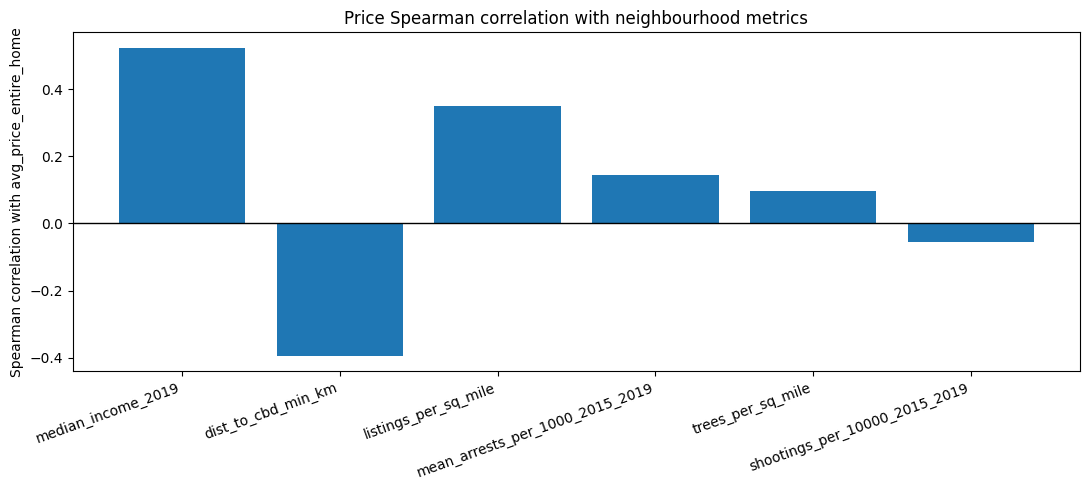

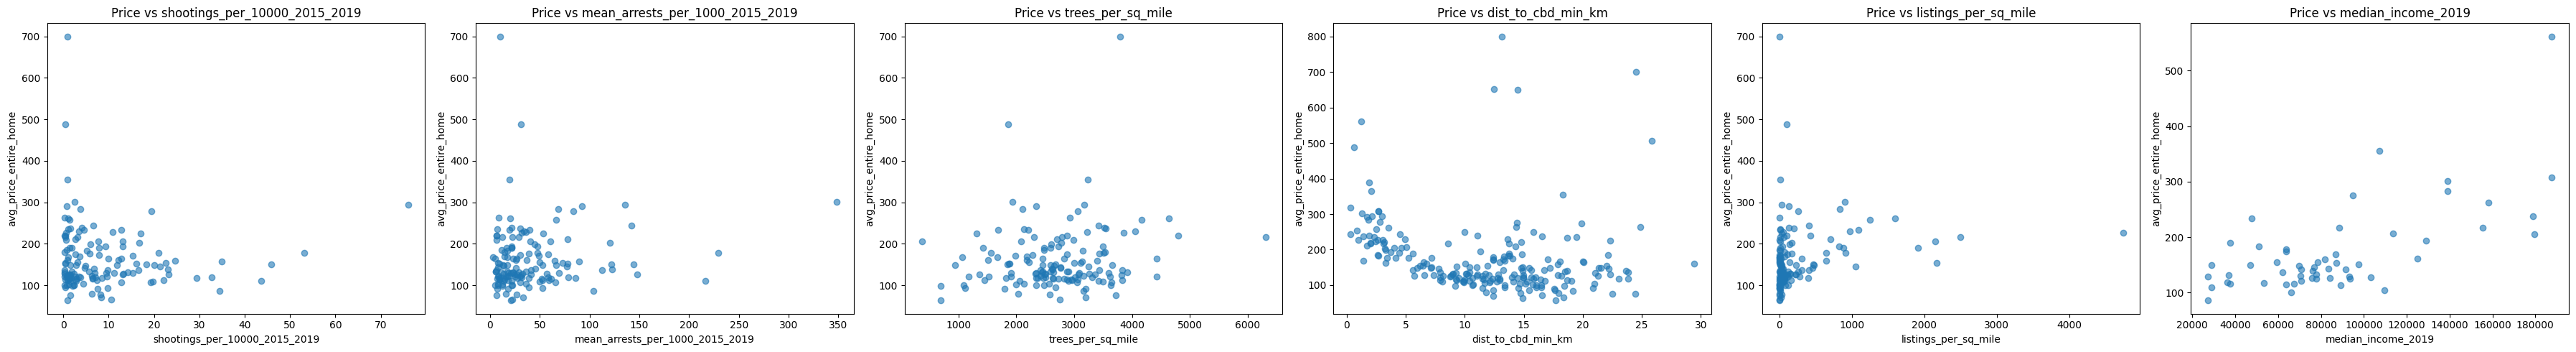

In [48]:
# Combined correlation view: listing-level + neighbourhood-level
 # 1) Listing-level: price vs distance to CBD
listing_level_df = airbnb_nyc_df[['price', 'dist_to_cbd_min_km']].copy()
listing_level_df['price'] = pd.to_numeric(listing_level_df['price'], errors='coerce')
listing_level_df['dist_to_cbd_min_km'] = pd.to_numeric(listing_level_df['dist_to_cbd_min_km'], errors='coerce')
before = len(listing_level_df)
listing_level_df = listing_level_df.dropna(subset=['price', 'dist_to_cbd_min_km']).copy()
print(f'Dropped {before - len(listing_level_df)} rows with missing price or CBD distance ({len(listing_level_df)} rows remaining)')

listing_cbd_corr_summary = pd.DataFrame([
    {
        'variable': 'dist_to_cbd_min_km (listing-level)',
        'spearman_corr_with_price': listing_level_df['price'].corr(listing_level_df['dist_to_cbd_min_km'], method='spearman'),
        'rows_used': len(listing_level_df),
    }
])

print('Listing-level Spearman correlation: price vs dist_to_cbd_min_km')
display(listing_cbd_corr_summary)

# 2) Neighbourhood-level: raw average price vs neighbourhood metrics
# Add listing density: listings_per_sq_mile.
listing_density_df = (
    airbnb_nyc_df[['neighbourhood']]
    .dropna(subset=['neighbourhood'])
    .copy()
)
listing_density_df = (
    listing_density_df
    .groupby('neighbourhood', as_index=False)
    .size()
    .rename(columns={'size': 'listing_count'})
)

listing_density_df = listing_density_df.merge(
    neighborhood_area_df[['neighbourhood', 'area_sq_miles']],
    on='neighbourhood',
    how='inner',
)
listing_density_df = listing_density_df[listing_density_df['area_sq_miles'] > 0].copy()
listing_density_df['listings_per_sq_mile'] = (
    listing_density_df['listing_count'] / listing_density_df['area_sq_miles']
)

corr_source = neighbourhood_combined_metrics.merge(
    cbd_distance_by_neighbourhood,
    on='neighbourhood',
    how='left',
).merge(
    listing_density_df[['neighbourhood', 'listings_per_sq_mile']],
    on='neighbourhood',
    how='left',
).merge(
    median_income_by_neighbourhood,
    on='neighbourhood',
    how='left',
)

corr_cols = [
    'avg_price_entire_home',
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'listings_per_sq_mile',
    'median_income_2019',
]

corr_df = corr_source[corr_cols].copy()
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')

# Spearman correlations with average price
target = 'avg_price_entire_home'
feature_cols = [c for c in corr_cols if c != target]

def spearman_with_p(x, y):
    mask = x.notna() & y.notna()
    r, p = stats.spearmanr(x[mask], y[mask])
    return r, p

_spearman_results = {c: spearman_with_p(corr_df[target], corr_df[c]) for c in feature_cols}
corr_summary = pd.DataFrame([
    {
        'variable': c,
        'spearman_corr_with_price': _spearman_results[c][0],
        'p_value': _spearman_results[c][1],
    }
    for c in feature_cols
])

corr_summary = corr_summary.sort_values('spearman_corr_with_price', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print('Spearman correlation with avg_price_entire_home (neighbourhood level):')
display(corr_summary)

# Bar chart of Spearman correlations
plt.figure(figsize=(11, 5))
plt.bar(corr_summary['variable'], corr_summary['spearman_corr_with_price'])
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=20, ha='right')
plt.ylabel('Spearman correlation with avg_price_entire_home')
plt.title('Price Spearman correlation with neighbourhood metrics')
plt.tight_layout()
plt.show()

# Scatter plots for each variable against price
fig, axes = plt.subplots(1, len(feature_cols), figsize=(36, 5))
if len(feature_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, feature_cols):
    plot_df = corr_df[[target, col]].dropna()
    ax.scatter(plot_df[col], plot_df[target], alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f'Price vs {col}')

plt.tight_layout()
plt.show()

**Interpretation.** Income and CBD proximity come out as the strongest associations with price, while safety and density variables contribute additional signal but rank lower. Since Spearman is rank-based, these results tell us about the direction of each relationship but not the size of the effect.

### Spearman correlation heatmap

**Goal:** Get a complete picture of how all the predictors relate to each other, not just to price, since strong correlations between predictors can distort the results of the linear model later.

To complement the pairwise correlation bars, we visualize the full Spearman correlation matrix across price and all neighbourhood-level predictors.

**Limitations:** The heatmap shows the strength of pairwise correlations but does not tell us which variable contributes most to explaining price once all others are already accounted for. It is best read as a diagnostic tool rather than a ranking.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Generate a Spearman correlation heatmap for average Airbnb price and all neighbourhood-level predictor variables using seaborn with annotated values and a diverging colour scale</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 3</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 3</td></tr>
</table>

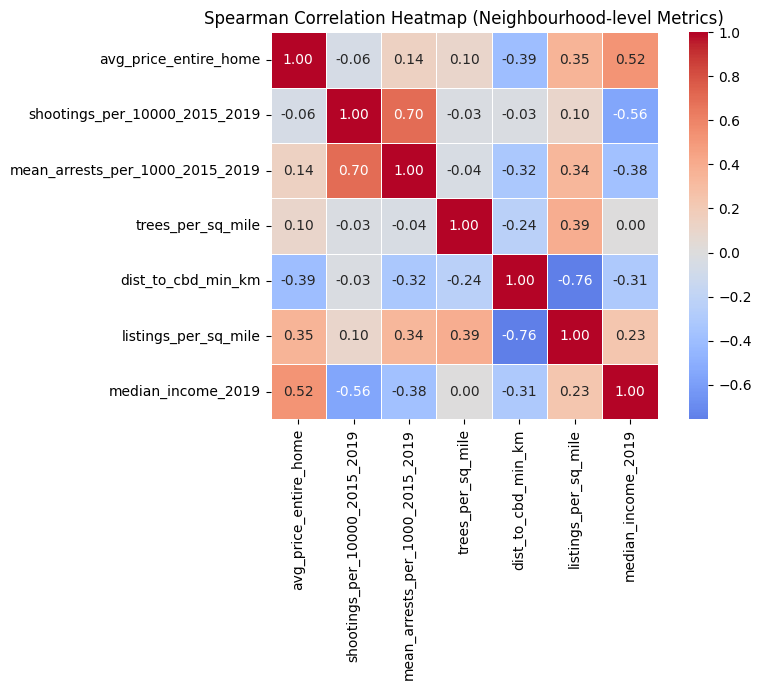

In [49]:
# Spearman heatmap for average price and neighbourhood-level predictors

spearman_matrix = corr_df.corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Spearman Correlation Heatmap (Neighbourhood-level Metrics)')
plt.tight_layout()
plt.show()

**Interpretation.** The heatmap confirms that some predictors are correlated with each other, not just with price. Income and CBD distance overlap noticeably, which means the linear model may split their combined effect across both variables rather than attributing it cleanly to one. This is worth keeping in mind when comparing the R² drop rankings against the tree-based results.

### Stepwise R-squared drop test

**Goal:** Rank each feature by how much explanatory power the model loses when that feature is removed, giving us a cleaner measure of individual importance than raw correlation coefficients.

To quantify feature impact in a unit-consistent way, we fit a full linear model on all neighbourhood-level predictors, then remove one feature at a time and measure the R-squared drop.

**Limitations:** This method is sensitive to multicollinearity. If two predictors share a lot of the same information, such as income and CBD distance, removing one may barely affect R² because the other compensates for it. This can make a genuinely important variable look less impactful than it really is, which is part of why we also validate with tree-based models.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Perform a stepwise R-squared drop test using linear regression to quantify the marginal contribution of each neighbourhood-level feature to predicting average Airbnb price for entire home listings</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 4</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 4</td></tr>
</table>

Full model R-squared: 0.4793
Full model Adjusted R-squared: 0.4031
Most impactful factor by R-squared drop: median_income_2019


,feature_removed,full_r2,reduced_r2,r2_drop,full_adjusted_r2,reduced_adjusted_r2,r2_drop_rank
0,median_income_2019,0.479262,0.361654,0.117608,0.403056,0.285660,1
1,listings_per_sq_mile,0.479262,0.416528,0.062734,0.403056,0.347067,2
2,mean_arrests_per_1000_2015_2019,0.479262,0.416618,0.062643,0.403056,0.347168,3
3,shootings_per_10000_2015_2019,0.479262,0.435623,0.043639,0.403056,0.368435,4
4,trees_per_sq_mile,0.479262,0.478011,0.001251,0.403056,0.415869,5
5,dist_to_cbd_min_km,0.479262,0.478880,0.000382,0.403056,0.416842,6


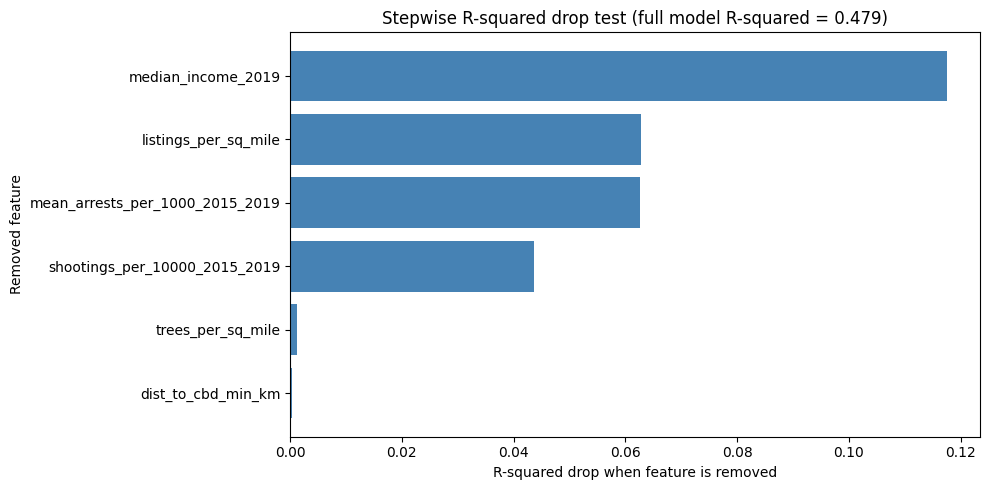

In [50]:
from sklearn.linear_model import LinearRegression

# Build modelling table from the neighbourhood-level analysis columns
model_features = [
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'listings_per_sq_mile',  # supply-side control: denser markets face more competition, which may suppress prices
    'median_income_2019',
]
model_target = 'avg_price_entire_home'  # room-type-controlled: entire home/apt only

# Subset the dataset to the target and features, coerce to numeric, and drop incomplete rows
r2_data = corr_source[[model_target] + model_features].copy()
r2_data = r2_data.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

X_full = r2_data[model_features]
y_full = r2_data[model_target]

# Fit the full model using all features to establish the baseline R-squared
base_lr = LinearRegression()
base_lr.fit(X_full, y_full)
base_r2 = base_lr.score(X_full, y_full)


# Helper to compute adjusted R-squared, which penalises adding extra predictors
def adjusted_r2(r2_value, n_obs, n_features):
    if n_obs <= n_features + 1:
        return np.nan
    return 1 - (1 - r2_value) * (n_obs - 1) / (n_obs - n_features - 1)


base_adj_r2 = adjusted_r2(base_r2, len(r2_data), X_full.shape[1])

# Stepwise test: remove one feature at a time and measure the drop in R-squared
# A larger drop means the removed feature carries more unique explanatory power
stepwise_rows = []
for feature in model_features:
    reduced_features = [f for f in model_features if f != feature]
    reduced_lr = LinearRegression()
    reduced_lr.fit(r2_data[reduced_features], y_full)
    reduced_r2 = reduced_lr.score(r2_data[reduced_features], y_full)
    reduced_adj_r2 = adjusted_r2(reduced_r2, len(r2_data), len(reduced_features))

    stepwise_rows.append({
        'feature_removed': feature,
        'full_r2': base_r2,
        'reduced_r2': reduced_r2,
        'r2_drop': base_r2 - reduced_r2,
        'full_adjusted_r2': base_adj_r2,
        'reduced_adjusted_r2': reduced_adj_r2,
    })

# Sort by R-squared drop descending and assign integer ranks
r2_drop_df = pd.DataFrame(stepwise_rows).sort_values('r2_drop', ascending=False).reset_index(drop=True)
r2_drop_df['r2_drop_rank'] = np.arange(1, len(r2_drop_df) + 1)

print(f'Full model R-squared: {base_r2:.4f}')
print(f'Full model Adjusted R-squared: {base_adj_r2:.4f}')
print('Most impactful factor by R-squared drop:', r2_drop_df.loc[0, 'feature_removed'])
display(r2_drop_df)

# Bar chart of R-squared drop per feature, ordered from most to least impactful
plt.figure(figsize=(10, 5))
plt.barh(r2_drop_df['feature_removed'], r2_drop_df['r2_drop'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('R-squared drop when feature is removed')
plt.ylabel('Removed feature')
plt.title(f'Stepwise R-squared drop test (full model R-squared = {base_r2:.3f})')
plt.tight_layout()
plt.show()

**Interpretation.** The R² drop results show which features the linear model actually relies on once everything else is already included. Features that rank highly here are genuinely adding something that the other predictors cannot substitute for, making this a more honest measure of importance than raw correlations.

### Machine learning validation (default models)

**Goal:** Check whether the ranking from the linear R² drop test holds up when we use models that can capture non-linear relationships and interactions between features.

We validate the linear-model impact ranking with three regression models using default hyperparameters: Decision Tree, Random Forest, and XGBoost.

**Limitations:** All three models are run with default hyperparameters and on a small neighbourhood-level sample, so importance scores should be treated as directional evidence rather than precise measurements. Tuning depth and regularization parameters could shift the relative rankings, which is why we compare across methods rather than relying on any single model.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Train Decision Tree, Random Forest, and XGBoost regression models on the neighbourhood-level feature set and extract and compare feature importance scores from each model</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 5</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 5</td></tr>
</table>

In [51]:
# Import the three tree-based regressors used for ML validation
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Prepare feature matrix and target vector from the neighbourhood-level dataset
X_ml = r2_data[model_features].copy()
y_ml = r2_data[model_target].copy()

# Instantiate all three models with a fixed random seed for reproducibility
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(random_state=42)

# Fit each model on the full dataset (no train/test split — used for importance ranking, not prediction)
dt_model.fit(X_ml, y_ml)
rf_model.fit(X_ml, y_ml)
xgb_model.fit(X_ml, y_ml)

# Collect feature importance scores from all three models into a single DataFrame
ml_importance_df = pd.DataFrame({
    'feature': model_features,
    'decision_tree_importance': dt_model.feature_importances_,
    'random_forest_importance': rf_model.feature_importances_,
    'xgboost_importance': xgb_model.feature_importances_,
})

# Display sorted by Random Forest importance as a reference ordering
print('Feature importances from default ML regressors:')
display(ml_importance_df.sort_values('random_forest_importance', ascending=False).reset_index(drop=True))

Feature importances from default ML regressors:


,feature,decision_tree_importance,random_forest_importance,xgboost_importance
0,dist_to_cbd_min_km,0.280225,0.365764,0.208164
1,median_income_2019,0.439988,0.343258,0.650495
2,shootings_per_10000_2015_2019,0.166016,0.100392,0.040896
3,listings_per_sq_mile,0.037138,0.083683,0.073867
4,mean_arrests_per_1000_2015_2019,0.059032,0.066939,0.017057
5,trees_per_sq_mile,0.017602,0.039964,0.009523


**Interpretation.** The three models broadly agree with the linear findings, which adds confidence that the rankings are not just an artefact of one method. Since none of the models are tuned, the exact importance scores are less meaningful than the overall pattern. What matters is whether the same features consistently rank near the top across all approaches.

### ML vs R-squared-drop comparison

We compare feature rankings across the stepwise R-squared-drop method and all ML models to check for consensus and method-specific differences.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Merge the stepwise R-squared drop rankings with feature importance scores from all three machine learning models into a single comparison table and produce side-by-side bar charts of feature rankings</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 6</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 6</td></tr>
</table>

Feature ranking comparison (R-squared drop vs ML importances):


,feature,decision_tree_importance,random_forest_importance,xgboost_importance,r2_drop,r2_drop_rank,decision_tree_rank,random_forest_rank,xgboost_rank,avg_rank
0,dist_to_cbd_min_km,0.280225,0.365764,0.208164,0.000382,6,2,1,2,2.75
1,median_income_2019,0.439988,0.343258,0.650495,0.117608,1,1,2,1,1.25
2,shootings_per_10000_2015_2019,0.166016,0.100392,0.040896,0.043639,4,3,3,4,3.50
3,listings_per_sq_mile,0.037138,0.083683,0.073867,0.062734,2,5,4,3,3.50
4,mean_arrests_per_1000_2015_2019,0.059032,0.066939,0.017057,0.062643,3,4,5,5,4.25
5,trees_per_sq_mile,0.017602,0.039964,0.009523,0.001251,5,6,6,6,5.75


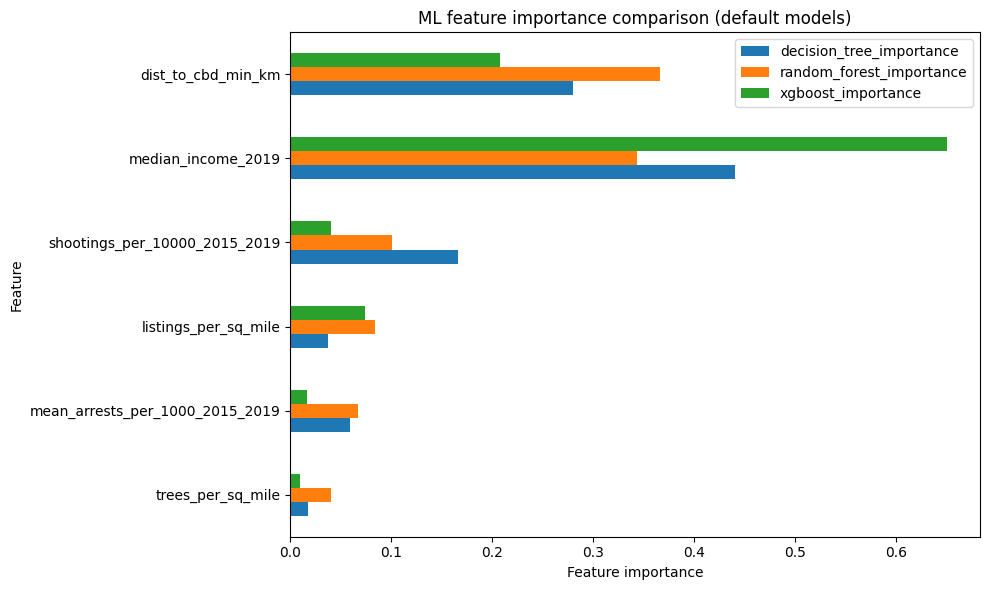

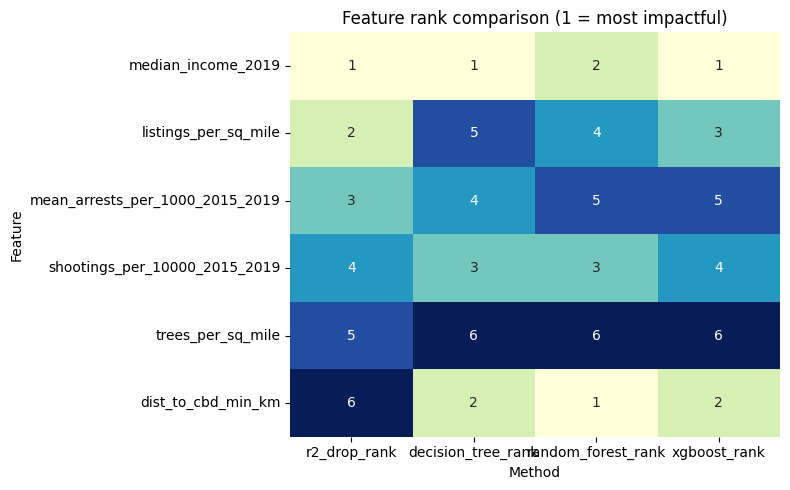

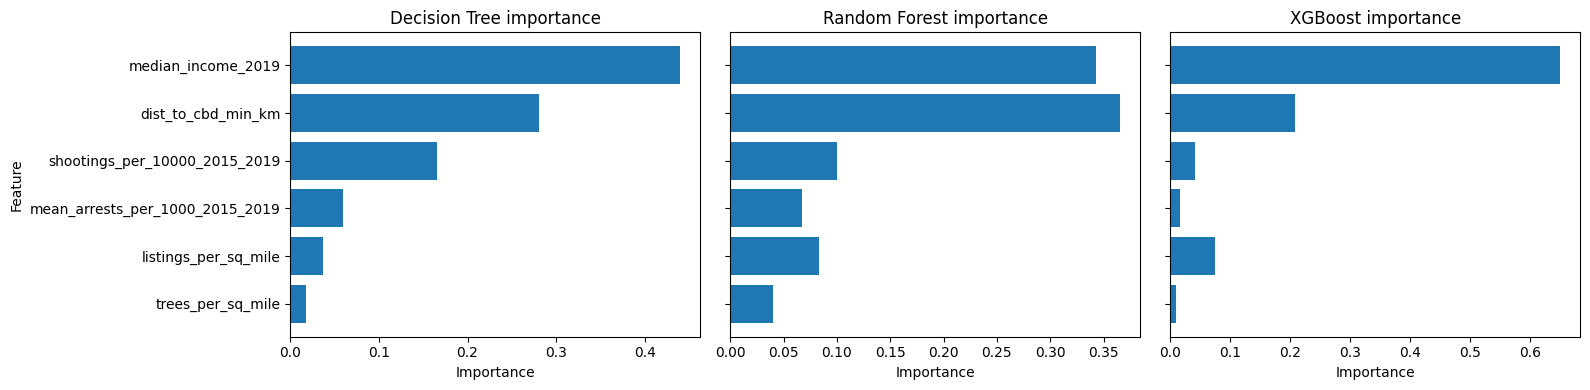

Consensus top feature (lowest average rank): median_income_2019


In [52]:
# Merge stepwise R-squared ranking with ML feature importances
r2_rank_view = r2_drop_df[['feature_removed', 'r2_drop', 'r2_drop_rank']].rename(columns={'feature_removed': 'feature'})

# Join on feature name so every row contains both R-squared-drop and ML importance scores
comparison_df = ml_importance_df.merge(r2_rank_view, on='feature', how='left')
comparison_df = comparison_df.sort_values('random_forest_importance', ascending=False).reset_index(drop=True)

# Convert raw importance scores to ordinal ranks (rank 1 = most important)
comparison_df['decision_tree_rank'] = comparison_df['decision_tree_importance'].rank(ascending=False, method='min').astype(int)
comparison_df['random_forest_rank'] = comparison_df['random_forest_importance'].rank(ascending=False, method='min').astype(int)
comparison_df['xgboost_rank'] = comparison_df['xgboost_importance'].rank(ascending=False, method='min').astype(int)

# Average rank across all four methods to get a consensus ordering
comparison_df['avg_rank'] = comparison_df[[
    'r2_drop_rank', 'decision_tree_rank', 'random_forest_rank', 'xgboost_rank'
]].mean(axis=1)

print('Feature ranking comparison (R-squared drop vs ML importances):')
display(comparison_df)

# Grouped horizontal bar chart of ML feature importances
plot_df = comparison_df.set_index('feature')[[
    'decision_tree_importance',
    'random_forest_importance',
    'xgboost_importance',
]].sort_values('random_forest_importance', ascending=True)

plot_df.plot(kind='barh', figsize=(10, 6))
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.title('ML feature importance comparison (default models)')
plt.tight_layout()
plt.show()

# Rank heatmap: shows ordinal position of each feature across all four methods
rank_heatmap_df = comparison_df.set_index('feature')[[
    'r2_drop_rank',
    'decision_tree_rank',
    'random_forest_rank',
    'xgboost_rank'
]].sort_values('r2_drop_rank')

plt.figure(figsize=(8, 5))
sns.heatmap(rank_heatmap_df, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Feature rank comparison (1 = most impactful)')
plt.xlabel('Method')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Individual importance bar charts, one per model, shown side by side for direct comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, col, title in [
    (axes[0], 'decision_tree_importance', 'Decision Tree'),
    (axes[1], 'random_forest_importance', 'Random Forest'),
    (axes[2], 'xgboost_importance', 'XGBoost'),
]:
    model_view = comparison_df[['feature', col]].sort_values(col, ascending=True)
    ax.barh(model_view['feature'], model_view[col])
    ax.set_title(f'{title} importance')
    ax.set_xlabel('Importance')

axes[0].set_ylabel('Feature')
plt.tight_layout()
plt.show()

# Identify the feature with the lowest average rank across all methods
consensus_top_feature = comparison_df.sort_values('avg_rank', ascending=True).iloc[0]['feature']
print('Consensus top feature (lowest average rank):', consensus_top_feature)

**Interpretation.** Where rankings differ across methods, that is not necessarily a problem. Tree models pick up on non-linear effects and feature interactions that the linear model cannot capture, so some disagreement is expected. The more useful question is which features appear near the top consistently, regardless of method.

### Interaction variables (exploratory)

**Goal:** Test whether the relationship between one factor and price changes depending on the value of another factor, for example whether the effect of CBD distance on price is stronger in wealthier neighbourhoods.

We test whether combined effects (interaction terms) improve explanatory power beyond the additive linear model.

**Limitations:** Interaction terms increase model complexity and are harder to interpret, particularly with a small neighbourhood-level sample where the risk of overfitting is real. Any improvement in R² here should be read cautiously rather than as confirmation that the interaction effect is meaningful.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Create interaction terms between median income and each of the other predictors including CBD distance, shooting rate, and arrest rate, then test whether adding these interaction features improves the linear model R-squared</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 7</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 7</td></tr>
</table>

In [53]:
# Copy the base dataset so the original r2_data is not modified
interaction_df = r2_data.copy()

# Create interaction terms: multiply median income by each spatial/safety feature
# This tests whether income amplifies or dampens the effect of each predictor on price
interaction_df['income_x_cbd'] = interaction_df['median_income_2019'] * interaction_df['dist_to_cbd_min_km']
interaction_df['income_x_shootings'] = interaction_df['median_income_2019'] * interaction_df['shootings_per_10000_2015_2019']
interaction_df['income_x_arrests'] = interaction_df['median_income_2019'] * interaction_df['mean_arrests_per_1000_2015_2019']

# Extend the base feature list with the three new interaction terms
interaction_features = model_features + [
    'income_x_cbd',
    'income_x_shootings',
    'income_x_arrests',
]

# Fit a linear regression using the expanded feature set (base + interaction terms)
interaction_lr = LinearRegression()
interaction_lr.fit(interaction_df[interaction_features], interaction_df[model_target])

# Compute R-squared and adjusted R-squared for the interaction model
interaction_r2 = interaction_lr.score(interaction_df[interaction_features], interaction_df[model_target])
interaction_adj_r2 = adjusted_r2(interaction_r2, len(interaction_df), len(interaction_features))

# Compare against the base additive model to quantify the R-squared gain from adding interactions
r2_gain = interaction_r2 - base_r2

print(f'Base additive model R-squared: {base_r2:.4f}')
print(f'Interaction model R-squared: {interaction_r2:.4f}')
print(f'R-squared gain from interactions: {r2_gain:.4f}')
print(f'Interaction model Adjusted R-squared: {interaction_adj_r2:.4f}')

# Build a coefficient table sorted by absolute magnitude to identify the strongest effects
interaction_coef_df = pd.DataFrame({
    'feature': interaction_features,
    'coefficient': interaction_lr.coef_,
}).sort_values('coefficient', key=lambda x: np.abs(x), ascending=False)

print('Largest interaction coefficients (directional):')
display(interaction_coef_df.head(8))

Base additive model R-squared: 0.4793
Interaction model R-squared: 0.4889
R-squared gain from interactions: 0.0096
Interaction model Adjusted R-squared: 0.3678
Largest interaction coefficients (directional):


,feature,coefficient
3,dist_to_cbd_min_km,1.413842
1,mean_arrests_per_1000_2015_2019,0.182071
0,shootings_per_10000_2015_2019,-0.142315
4,listings_per_sq_mile,0.032882
2,trees_per_sq_mile,0.001797
5,median_income_2019,0.000807
7,income_x_shootings,-0.000018
6,income_x_cbd,-0.000014


**Interpretation.** If adding interaction terms improves R², it suggests that the effect of one factor on price depends on the level of another. For example, CBD proximity may matter more in wealthier neighbourhoods than in poorer ones. Any improvement here should be read cautiously given the small sample size, but it points to where the simple additive model may be oversimplifying things.

### Linear-model residual diagnostics

**Goal:** Check whether a linear model is actually a reasonable fit for this data, or whether the residuals show patterns that suggest we are missing something important.

Residual diagnostics help us assess whether a linear form is a reasonable approximation for this explanatory analysis.

**Limitations:** With only around 100 neighbourhood-level observations, formal normality tests are not very reliable and visual inspection carries more weight. Any fan-shaped spread or curvature in the residual plots signals non-linearity or heteroscedasticity, but with this sample size it is difficult to distinguish a genuine structural issue from noise.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Generate residual diagnostic plots for the full linear regression model including a predicted versus actual scatter plot and a residuals versus predicted values plot to assess model fit and heteroscedasticity</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 8</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 8</td></tr>
</table>

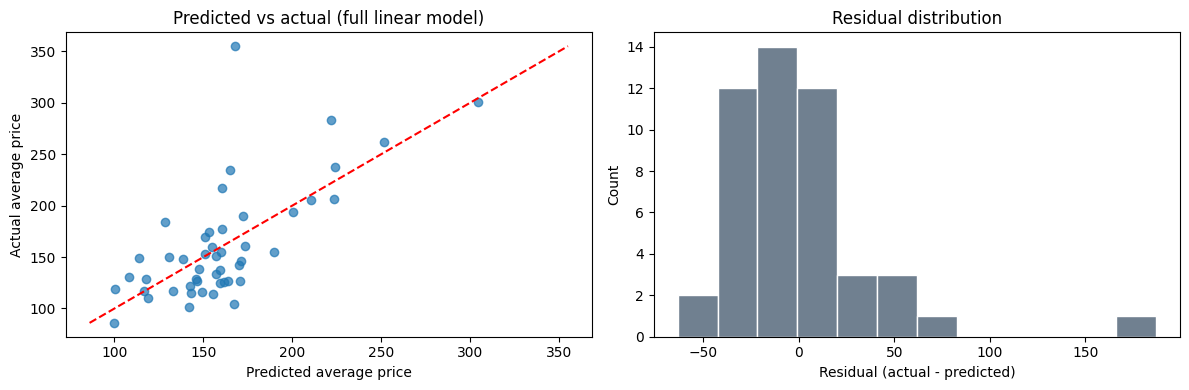

In [54]:
y_pred_full = base_lr.predict(X_full)
residuals_full = y_full - y_pred_full

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_full, y_full, alpha=0.7)
min_val = min(y_full.min(), y_pred_full.min())
max_val = max(y_full.max(), y_pred_full.max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='red')
axes[0].set_xlabel('Predicted average price')
axes[0].set_ylabel('Actual average price')
axes[0].set_title('Predicted vs actual (full linear model)')

axes[1].hist(residuals_full, bins=12, color='slategray', edgecolor='white')
axes[1].set_xlabel('Residual (actual - predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.show()

**Interpretation.** The residual plots give us a sense of where the linear model struggles. Curvature in the predicted vs actual plot or a fan-shaped spread in the residuals would suggest that some relationships are non-linear or that important predictors are still missing from the model.

### Choropleth maps: spatial distribution of outcomes

**Goal:** Check whether pricing patterns cluster geographically, since if they do it suggests that neighbourhood location matters beyond what individual features alone can explain.

These maps visualize neighbourhood-level average Airbnb price and the top factor identified by the stepwise R-squared-drop test.

**Limitations:** The choropleths show neighbourhood averages, so within-neighbourhood variation is hidden. Additionally, because neighbourhood names are matched using fuzzy string matching rather than exact joins, a small number of polygons may be misaligned with the correct Airbnb neighbourhood label.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Generate choropleth maps of New York City neighbourhoods to visualise the spatial distribution of average Airbnb price and each neighbourhood-level predictor variable using the GeoJSON boundary file</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 9</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 9</td></tr>
</table>

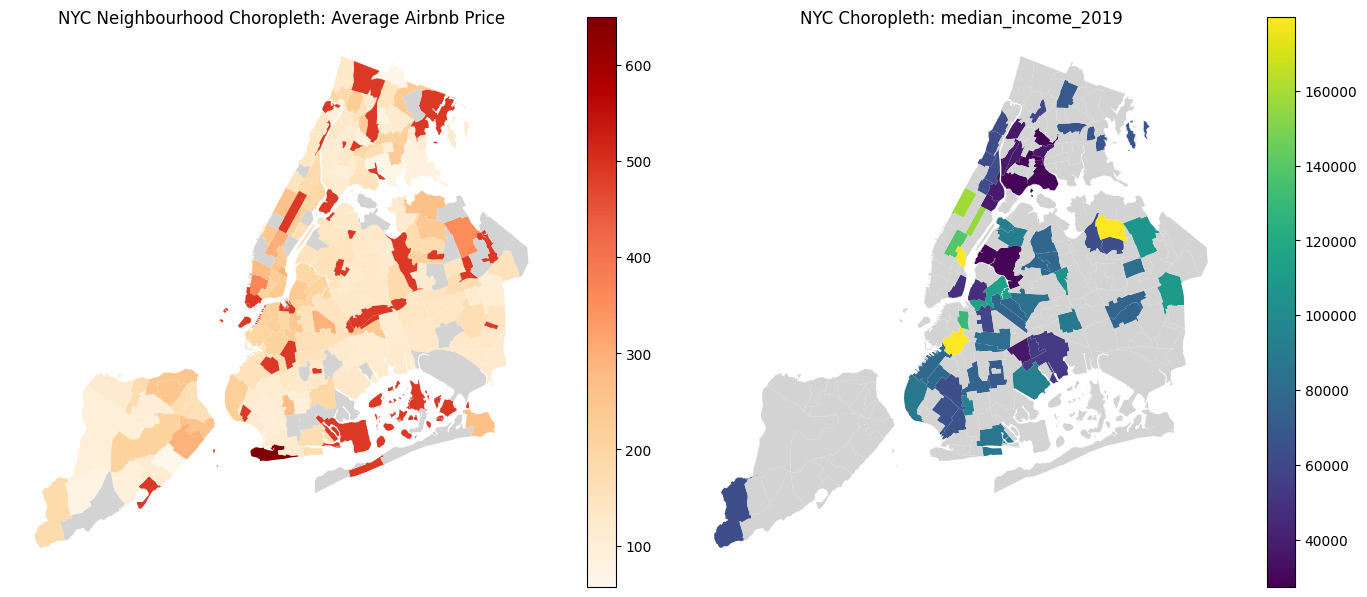

In [55]:
map_df = corr_source[['neighbourhood', 'avg_price_entire_home'] + model_features].copy()
map_df = map_df.apply(lambda col: pd.to_numeric(col, errors='coerce') if col.name != 'neighbourhood' else col)

nyc_map = nyc_gdf.copy()

# Robustly detect the neighbourhood name column from nycgeo variants.
name_col = None
for c in nyc_map.columns:
    cl = str(c).lower().replace('_', '').replace(' ', '')
    if 'nta' in cl and 'name' in cl:
        name_col = c
        break

if name_col is None:
    for fallback in ['neighbourhood', 'neighborhood', 'name']:
        if fallback in nyc_map.columns:
            name_col = fallback
            break

if name_col is None:
    raise KeyError(
        f"Could not find neighbourhood name column in nyc_gdf. Available columns: {list(nyc_map.columns)}"
    )

nyc_map['geo_neighbourhood_raw'] = nyc_map[name_col].astype(str)
nyc_map['geo_neighbourhood_clean'] = nyc_map['geo_neighbourhood_raw'].map(clean_neighbourhood_keep_coop)

neighbourhood_lookup = map_df['neighbourhood'].dropna().astype(str).unique().tolist()

def fuzzy_match_single_name(name, choices, threshold=75):
    if pd.isna(name):
        return None
    name = str(name).strip()
    if not name:
        return None
    best = process.extractOne(name, choices)
    if best is None:
        return None
    match, score = best
    return match if score >= threshold else None

nyc_map['neighbourhood'] = nyc_map['geo_neighbourhood_clean'].map(
    lambda x: fuzzy_match_single_name(x, neighbourhood_lookup)
)

map_join = nyc_map.merge(map_df, on='neighbourhood', how='left')

top_r2_feature = r2_drop_df.loc[0, 'feature_removed']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

map_join.plot(
    column='avg_price_entire_home',
    cmap='OrRd',
    legend=True,
    ax=axes[0],
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
axes[0].set_title('NYC Neighbourhood Choropleth: Average Airbnb Price')
axes[0].axis('off')

map_join.plot(
    column=top_r2_feature,
    cmap='viridis',
    legend=True,
    ax=axes[1],
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
axes[1].set_title(f'NYC Choropleth: {top_r2_feature}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Interpretation.** The maps show that price does not distribute randomly across NYC. There is clear geographic clustering, with higher prices concentrated in certain areas and lower prices in others. This suggests that where a listing is located matters in ways that go beyond just the individual features we measured.

### Pair plot and room-type distribution

These plots provide supplementary evidence on multivariate relationships and within-market price dispersion by room type.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Create a pair plot for the top four features from the R-squared drop ranking and a violin plot combined with a box plot showing Airbnb listing price distribution by room type</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 10</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 10</td></tr>
</table>

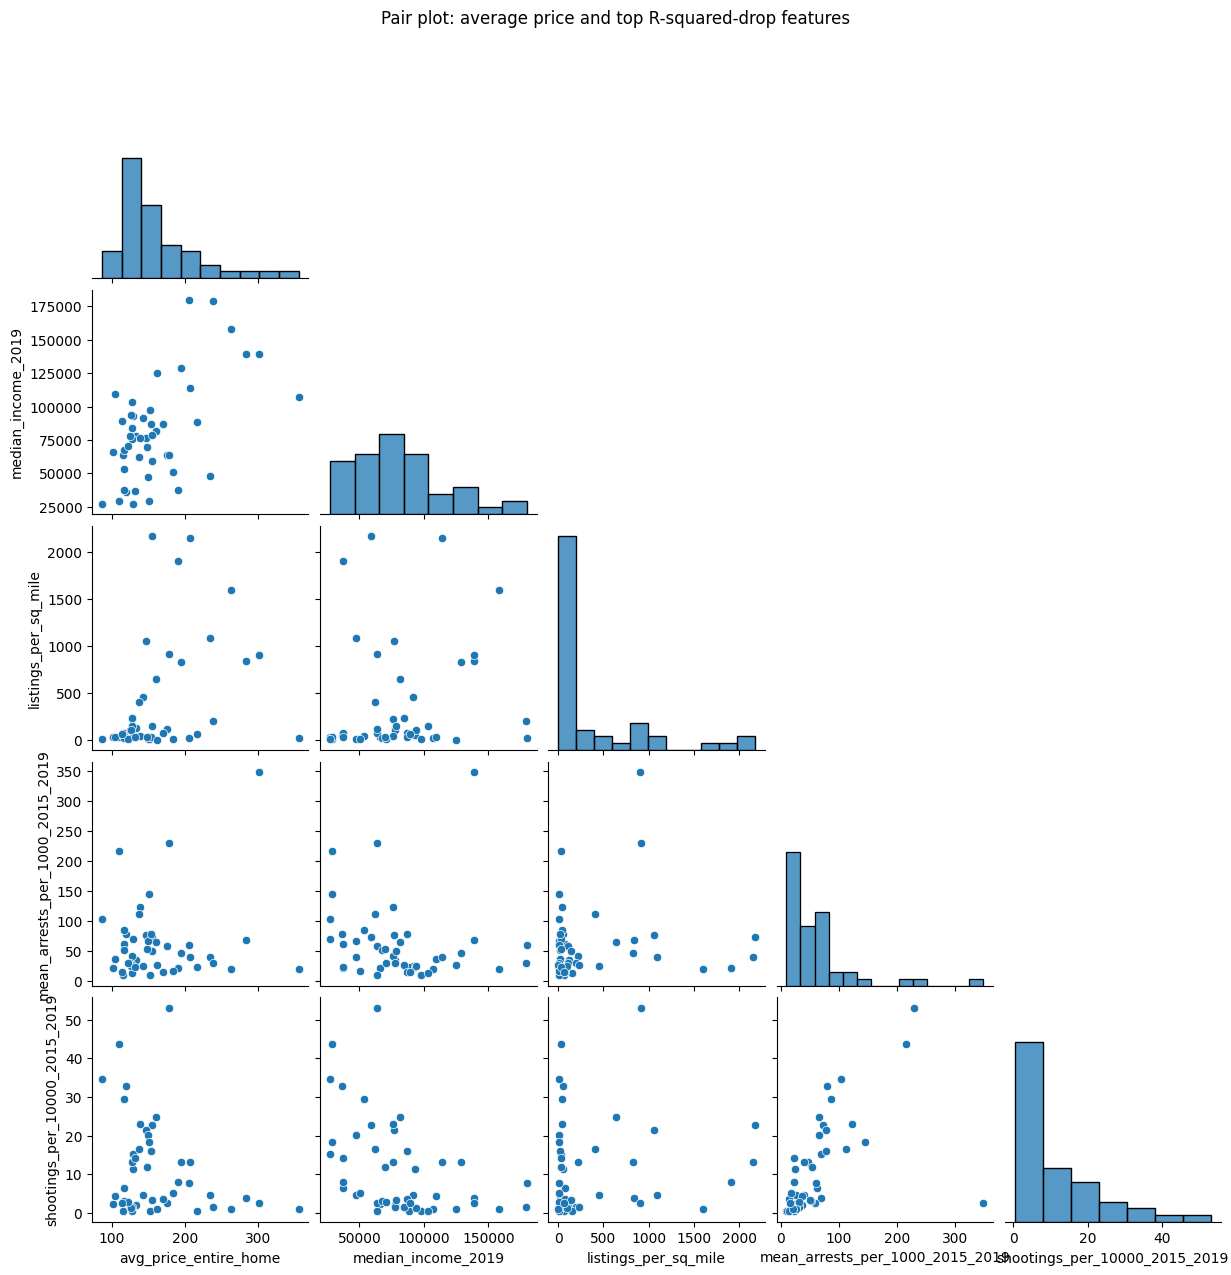

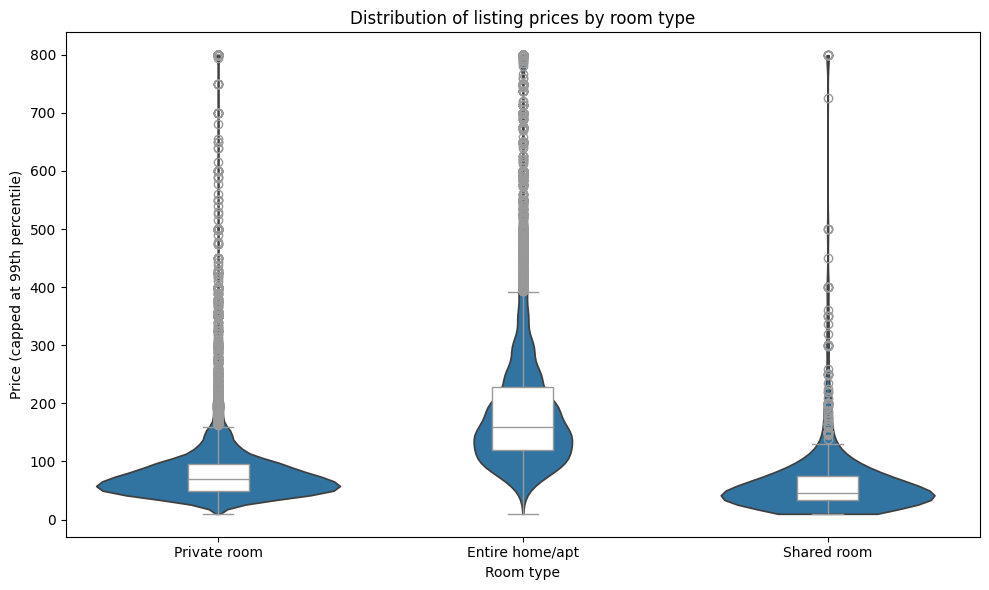

In [56]:
# Pair plot for top features from R-squared-drop ranking
top_features_for_pairplot = r2_drop_df['feature_removed'].head(4).tolist()
pairplot_df = r2_data[[model_target] + top_features_for_pairplot].dropna().copy()

sns.pairplot(pairplot_df, corner=True, diag_kind='hist')
plt.suptitle('Pair plot: average price and top R-squared-drop features', y=1.02)
plt.show()

# Violin + box plot for listing-level price by room type
room_price_df = airbnb_nyc_df[['room_type', 'price']].copy()
room_price_df['price'] = pd.to_numeric(room_price_df['price'], errors='coerce')
room_price_df = room_price_df.dropna()
room_price_df = room_price_df[room_price_df['price'] > 0]
room_price_df['price_capped'] = room_price_df['price'].clip(upper=room_price_df['price'].quantile(0.99))

plt.figure(figsize=(10, 6))
sns.violinplot(data=room_price_df, x='room_type', y='price_capped', inner=None, cut=0)
sns.boxplot(data=room_price_df, x='room_type', y='price_capped', width=0.2, color='white')
plt.xlabel('Room type')
plt.ylabel('Price (capped at 99th percentile)')
plt.title('Distribution of listing prices by room type')
plt.tight_layout()
plt.show()

**Interpretation.** The pair plots show that the relationships between price and the top features are not clean straight lines, with visible clustering and curvature across several pairs. The room-type distribution also highlights that part of the price variation across neighbourhoods may simply reflect what types of listings are available there, with entire-home listings consistently commanding higher prices than private or shared rooms.

### Data coverage check and profiling

Before deeper comparisons, we profile the merged neighbourhood-level analysis table to inspect coverage and missingness for each derived metric.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Profile the integrated neighbourhood analysis table for missing values and display descriptive statistics for all neighbourhood-level features that are used in the modelling pipeline</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 11</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 11</td></tr>
</table>

In [57]:
# Define the columns needed for the neighbourhood-level analysis and modelling pipeline
analysis_cols = [
    'neighbourhood',
    'avg_price_entire_home',
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'listings_per_sq_mile',
    'median_income_2019',
]

# Subset the integrated source table to only these columns
analysis_table = corr_source[analysis_cols].copy()

# Count missing values per column and express as a percentage of total rows
# Sorted descending so the most incomplete variables appear first
missing_profile = (
    analysis_table
    .isna()
    .sum()
    .to_frame('missing_count')
    .assign(missing_pct=lambda d: (d['missing_count'] / len(analysis_table) * 100).round(2))
    .sort_values('missing_count', ascending=False)
)

print('Missing-value profile for integrated neighbourhood analysis table:')
display(missing_profile)

# Descriptive statistics for all numeric features — gives a sense of scale, spread, and outliers
print('Summary statistics for numeric variables used in analysis:')
display(
    analysis_table
    .drop(columns=['neighbourhood'])
    .apply(pd.to_numeric, errors='coerce')
    .describe()
    .T
)

# Report the total number of neighbourhood rows available after integration
print(f'Total neighbourhood rows in integrated table: {len(analysis_table)}')

Missing-value profile for integrated neighbourhood analysis table:


,missing_count,missing_pct
median_income_2019,165,75.00
shootings_per_10000_2015_2019,84,38.18
mean_arrests_per_1000_2015_2019,75,34.09
trees_per_sq_mile,75,34.09
listings_per_sq_mile,75,34.09
avg_price_entire_home,5,2.27
neighbourhood,0,0.00
dist_to_cbd_min_km,0,0.00


Summary statistics for numeric variables used in analysis:


,count,mean,std,min,25%,50%,75%,max
avg_price_entire_home,215.0,175.402224,104.314243,57.000000,117.615534,148.315789,205.977393,800.000000
shootings_per_10000_2015_2019,136.0,8.713819,11.406169,0.247614,1.333936,4.451915,12.253441,76.013112
mean_arrests_per_1000_2015_2019,145.0,41.509872,46.247478,3.080318,14.507579,26.481238,52.382043,348.250087
trees_per_sq_mile,145.0,2694.707040,872.888126,367.647832,2181.220152,2678.468993,3203.753002,6307.779110
dist_to_cbd_min_km,220.0,11.931923,6.396123,0.329212,7.149671,12.398754,16.441948,29.431199
listings_per_sq_mile,145.0,246.616552,575.933898,0.429131,11.182004,44.546233,160.845287,4740.312929
median_income_2019,55.0,86127.291142,41458.444654,27324.753710,62763.587530,77790.755090,100372.890035,187634.991600


Total neighbourhood rows in integrated table: 220


This profiling step lets us check how complete the integrated table is before drawing conclusions. Any variables with notable missingness should be kept in mind when interpreting results, since gaps in coverage can affect how representative the neighbourhood-level averages actually are.

### Borough-level comparison

To add interpretive context, we map each neighbourhood to its dominant borough (based on Airbnb listings) and compare borough-level price and feature aggregates.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Build a neighbourhood-to-borough lookup table from the Airbnb dataset by selecting the most frequent borough label per neighbourhood, then create a borough-level summary of average price and neighbourhood-level indicators</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 12</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 12</td></tr>
</table>

Borough-level contextual summary (means over mapped neighbourhoods):


,borough,neighbourhoods,avg_price,avg_shootings_per_10000,avg_arrests_per_1000,avg_trees_per_sq_mile,avg_median_income
2,Manhattan,32,260.705137,11.342467,76.996118,3183.595574,123369.860720
4,Staten Island,42,183.860569,5.708164,26.847976,2186.613612,102366.634337
1,Brooklyn,47,175.842645,9.911317,42.798914,2792.647957,82390.650642
3,Queens,51,154.241216,5.357547,27.214519,2654.571581,88860.367977
0,Bronx,48,130.613186,11.750489,47.374646,2684.595120,47000.617932


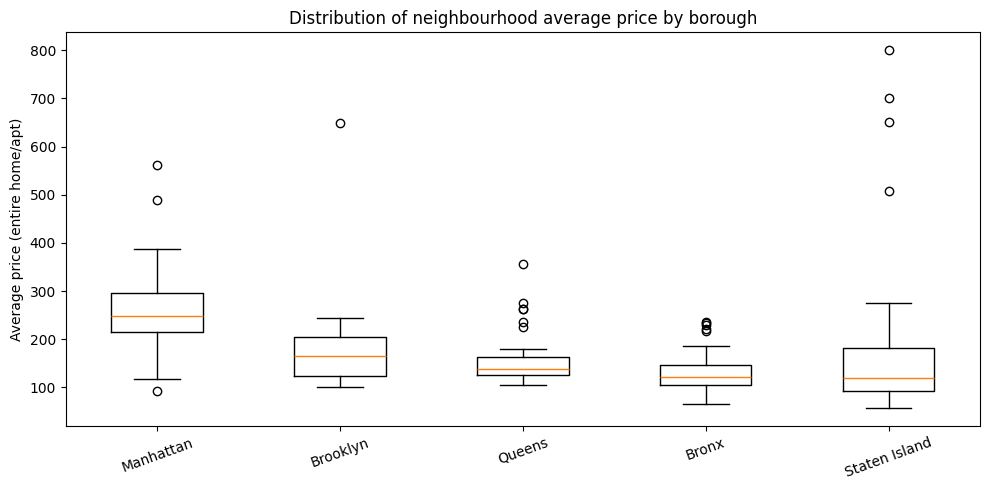

In [58]:
# Build neighbourhood-to-borough lookup using the most frequent borough per neighbourhood.
hood_borough_map = (
    airbnb_nyc_df[['neighbourhood', 'neighbourhood_group']]
    .dropna(subset=['neighbourhood', 'neighbourhood_group'])
    .copy()
)
hood_borough_map['neighbourhood'] = hood_borough_map['neighbourhood'].apply(clean_neighbourhood_keep_coop)
hood_borough_map = (
    hood_borough_map
    .groupby('neighbourhood')['neighbourhood_group']
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
    .reset_index()
    .rename(columns={'neighbourhood_group': 'borough'})
)

borough_analysis = analysis_table.merge(hood_borough_map, on='neighbourhood', how='left')

borough_summary = (
    borough_analysis
    .groupby('borough', as_index=False)
    .agg(
        neighbourhoods=('neighbourhood', 'nunique'),
        avg_price=('avg_price_entire_home', 'mean'),
        avg_shootings_per_10000=('shootings_per_10000_2015_2019', 'mean'),
        avg_arrests_per_1000=('mean_arrests_per_1000_2015_2019', 'mean'),
        avg_trees_per_sq_mile=('trees_per_sq_mile', 'mean'),
        avg_median_income=('median_income_2019', 'mean')
    )
    .sort_values('avg_price', ascending=False)
)

print('Borough-level contextual summary (means over mapped neighbourhoods):')
display(borough_summary)

# Price distribution by borough (neighbourhood-level average price).
plot_df = borough_analysis[['borough', 'avg_price_entire_home']].dropna()
borough_order = plot_df.groupby('borough')['avg_price_entire_home'].median().sort_values(ascending=False).index.tolist()
groups = [plot_df.loc[plot_df['borough'] == b, 'avg_price_entire_home'].values for b in borough_order]

plt.figure(figsize=(10, 5))
plt.boxplot(groups, tick_labels=borough_order)
plt.ylabel('Average price (entire home/apt)')
plt.title('Distribution of neighbourhood average price by borough')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Composite signal index

To bring all the factors together into a single view, we standardize each neighbourhood-level feature into z-scores and average them into a composite signal score. This lets us rank neighbourhoods by their overall desirability profile and check whether that composite score aligns with actual Airbnb prices, complementing the pairwise correlations from earlier.

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Standardize each neighbourhood-level feature into z-scores, compute a composite signal score by averaging them, and rank neighbourhoods by that score to show which areas have the strongest combined desirability profile relative to average Airbnb price</td></tr>
  <tr><td>Generated output</td><td>see code cell in Data Analysis - code cell 13</td></tr>
  <tr><td>Impacted notebook cell</td><td>Data Analysis - code cell 13</td></tr>
</table>

Top 10 neighbourhoods by composite signal score:


,neighbourhood,avg_price_entire_home,composite_signal_score
43,Upper West Side,262.045382,1.456505
28,Murray Hill,237.852130,1.327203
18,Fort Greene,193.726384,0.724541
22,Jackson Heights,124.689655,0.588017
9,Chelsea,283.262195,0.575905
32,Rego Park,127.125000,0.573444
33,Ridgewood,126.589147,0.516492
0,Astoria,142.199475,0.475141
1,Bay Ridge,216.757143,0.434021
5,Borough Park,114.653846,0.409739


Bottom 10 neighbourhoods by composite signal score:


,neighbourhood,avg_price_entire_home,composite_signal_score
27,Mott Haven,110.000000,-1.370662
19,Harlem,177.595560,-0.983982
11,Coney Island,149.400000,-0.937529
21,Hunts Point,150.000000,-0.868136
40,Tremont,86.000000,-0.754866
23,Jamaica,138.775000,-0.720702
6,Brownsville,119.105263,-0.658742
14,East New York,116.720430,-0.618472
39,Tottenville,160.800000,-0.469502
45,Williamsbridge,148.315789,-0.347827


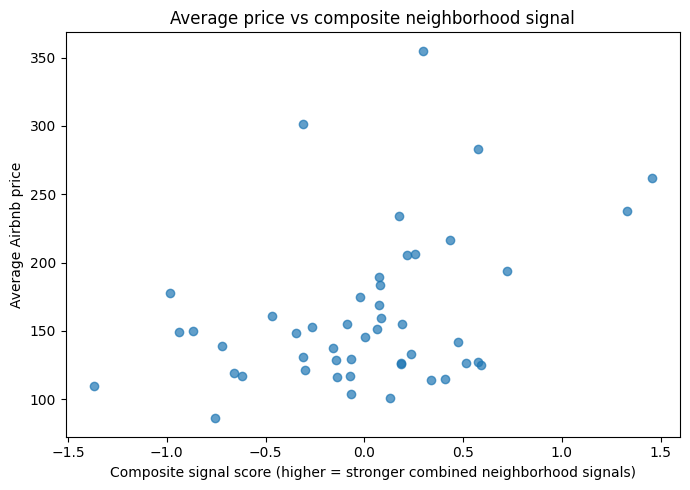

Spearman correlation: avg_price_entire_home vs composite_signal_score
0.28614850195397307


In [59]:
# Subset to the features used for the composite score, dropping rows with any missing values
rank_df = analysis_table[[
    'neighbourhood',
    'avg_price_entire_home',
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'median_income_2019',
]].copy()

rank_df = rank_df.dropna().reset_index(drop=True)

# Z-score utility with safe handling for zero-variance or all-NaN columns
def zscore_series(s):
    s = pd.to_numeric(s, errors='coerce')
    std = s.std(ddof=1)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

# Standardise each feature into z-scores
# Distance and crime rates are negated so that higher z-score always means 'more desirable'
rank_df['income_z'] = zscore_series(rank_df['median_income_2019'])
rank_df['greenery_z'] = zscore_series(rank_df['trees_per_sq_mile'])
rank_df['access_z'] = -zscore_series(rank_df['dist_to_cbd_min_km'])        # closer to CBD = better
rank_df['safety_shoot_z'] = -zscore_series(rank_df['shootings_per_10000_2015_2019'])  # fewer shootings = better
rank_df['safety_arrest_z'] = -zscore_series(rank_df['mean_arrests_per_1000_2015_2019'])  # fewer arrests = better

# Average the five z-scores into a single composite signal score per neighbourhood
rank_df['composite_signal_score'] = rank_df[
    ['income_z', 'greenery_z', 'access_z', 'safety_shoot_z', 'safety_arrest_z']
].mean(axis=1)

# Show the highest and lowest ranked neighbourhoods by composite score
top_signal = rank_df.sort_values('composite_signal_score', ascending=False).head(10)
bottom_signal = rank_df.sort_values('composite_signal_score', ascending=True).head(10)

print('Top 10 neighbourhoods by composite signal score:')
display(top_signal[['neighbourhood', 'avg_price_entire_home', 'composite_signal_score']])

print('Bottom 10 neighbourhoods by composite signal score:')
display(bottom_signal[['neighbourhood', 'avg_price_entire_home', 'composite_signal_score']])

# Scatter plot to visualise whether a stronger composite signal correlates with higher prices
plt.figure(figsize=(7, 5))
plt.scatter(rank_df['composite_signal_score'], rank_df['avg_price_entire_home'], alpha=0.7)
plt.xlabel('Composite signal score (higher = stronger combined neighborhood signals)')
plt.ylabel('Average Airbnb price')
plt.title('Average price vs composite neighborhood signal')
plt.tight_layout()
plt.show()

# Spearman correlation confirms whether the composite ranking aligns monotonically with price
print('Spearman correlation: avg_price_entire_home vs composite_signal_score')
print(rank_df['avg_price_entire_home'].corr(rank_df['composite_signal_score'], method='spearman'))

### Analytical Summary

Across all the methods used, income and CBD proximity emerge as the most consistent drivers of neighbourhood-level Airbnb prices, with safety and greenery playing a secondary but still meaningful role. No single method tells the full story on its own, which is why comparing across Spearman, the R² drop test, and three ML models gives us more confidence in the final rankings.

---

# Presentation of main results (Share)

## Key findings

These results are primarily aimed at **new Airbnb hosts** looking to set competitive prices. Rather than guessing, hosts can use the factor rankings below to understand what actually drives price differences across NYC neighbourhoods and position their listings accordingly.

After combining all methods (stepwise R-squared drop + Decision Tree + Random Forest + XGBoost), the variables are ranked by **overall impact on neighbourhood-level Airbnb price** as follows:

1. **`median_income_2019` (Most impactful overall)**
   - Ranked #1 in stepwise R-squared drop, Decision Tree, and XGBoost; ranked #2 in Random Forest.
   - Interpretation: neighbourhood purchasing power and amenity profile are the strongest consistent drivers of price.

2. **`dist_to_cbd_min_km`**
   - Ranked #1 in Random Forest and #2 in Decision Tree/XGBoost, but much lower in linear R-squared-drop.
   - Interpretation: CBD proximity has strong **non-linear** effects that tree models capture better than a purely additive linear model.

3. **`listings_per_sq_mile` (tied middle tier)**
   - Very strong in linear R-squared-drop (#2), but weaker in tree models.
   - Interpretation: local market intensity/competition matters, though the effect is model-dependent.

4. **`shootings_per_10000_2015_2019` (tied middle tier)**
   - Mid-level importance across methods.
   - Interpretation: safety risk contributes to pricing differences, but less than income and location.

5. **`mean_arrests_per_1000_2015_2019`**
   - Lower-ranked across most models.
   - Interpretation: arrest density adds explanatory value but is secondary once stronger structural variables are included.

6. **`trees_per_sq_mile` (Least impactful overall)**
   - Consistently lowest rank across methods.
   - Interpretation: greenery is directionally positive but contributes only a small incremental effect after controlling for income, access, and safety.

### Why `dist_to_cbd_min_km` looks contradictory across methods

A key apparent contradiction is that `dist_to_cbd_min_km` has a **near-zero R-squared drop** in the linear stepwise test, but **high importance** in Random Forest and XGBoost.

A possible reason for this pattern is:

- In the stepwise linear test, each variable is evaluated by its **unique additive contribution** after the other predictors are already in the model. If `dist_to_cbd_min_km` shares much of its linear signal with `median_income_2019` and `listings_per_sq_mile`, removing CBD leaves model fit almost unchanged, so the measured R-squared drop can be near 0.
- This does not mean CBD is unimportant. It means CBD adds little **additional linear variance** on top of the other predictors in that specific additive model.
- Tree models capture **non-linear thresholds and interactions** (for example, a steep premium very near Manhattan CBD and flatter effects farther away), so they still assign higher importance to CBD distance.
- Therefore, the correct interpretation is: CBD distance is a strong structural driver of price, but much of its effect is **shared and non-linear**, not purely additive-linear.



## Data Visualization & Relationships

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Create a bar chart showing the distribution of average Airbnb price across NYC boroughs with error bars representing one standard deviation</td></tr>
  <tr><td>Generated output</td><td>see code cell in Share - code cell 1</td></tr>
  <tr><td>Impacted notebook cell</td><td>Share - code cell 1</td></tr>
</table>

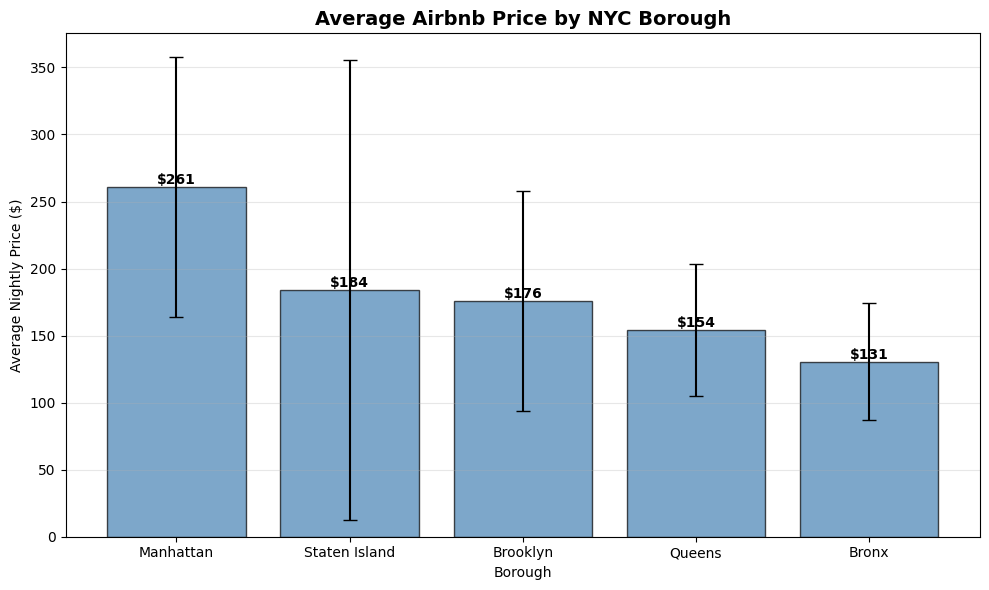

Average prices:          borough        mean         std  count
2      Manhattan  260.705137   96.834473     32
4  Staten Island  183.860569  171.525987     41
1       Brooklyn  175.842645   82.071599     47
3         Queens  154.241216   49.305068     49
0          Bronx  130.613186   43.347803     46


In [60]:
# Distribution of average price by borough

# Use borough_analysis which has the borough column
borough_price = borough_analysis.groupby('borough')['avg_price_entire_home'].agg(['mean', 'std', 'count']).reset_index()
borough_price = borough_price.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(borough_price['borough'], borough_price['mean'], yerr=borough_price['std'], capsize=5, alpha=0.7, color='steelblue', edgecolor='black')
ax.set_title('Average Airbnb Price by NYC Borough', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Nightly Price ($)')
ax.set_xlabel('Borough')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.0f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Average prices: {borough_price.to_string()}')

<table>
  <tr><td>GenAI tool name</td><td>Claude AI</td></tr>
  <tr><td>Input prompt</td><td>Create a two-by-two panel of scatter plots showing the relationships between average Airbnb price and the key predictor variables median income, shooting rate, and tree density, coloured by borough</td></tr>
  <tr><td>Generated output</td><td>see code cell in Share - code cell 2</td></tr>
  <tr><td>Impacted notebook cell</td><td>Share - code cell 2</td></tr>
</table>

C:\Users\nigel\AppData\Local\Temp\ipykernel_73220\2313600343.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_subset, x='borough', y='avg_price_entire_home', ax=axes[1, 1], palette='husl')


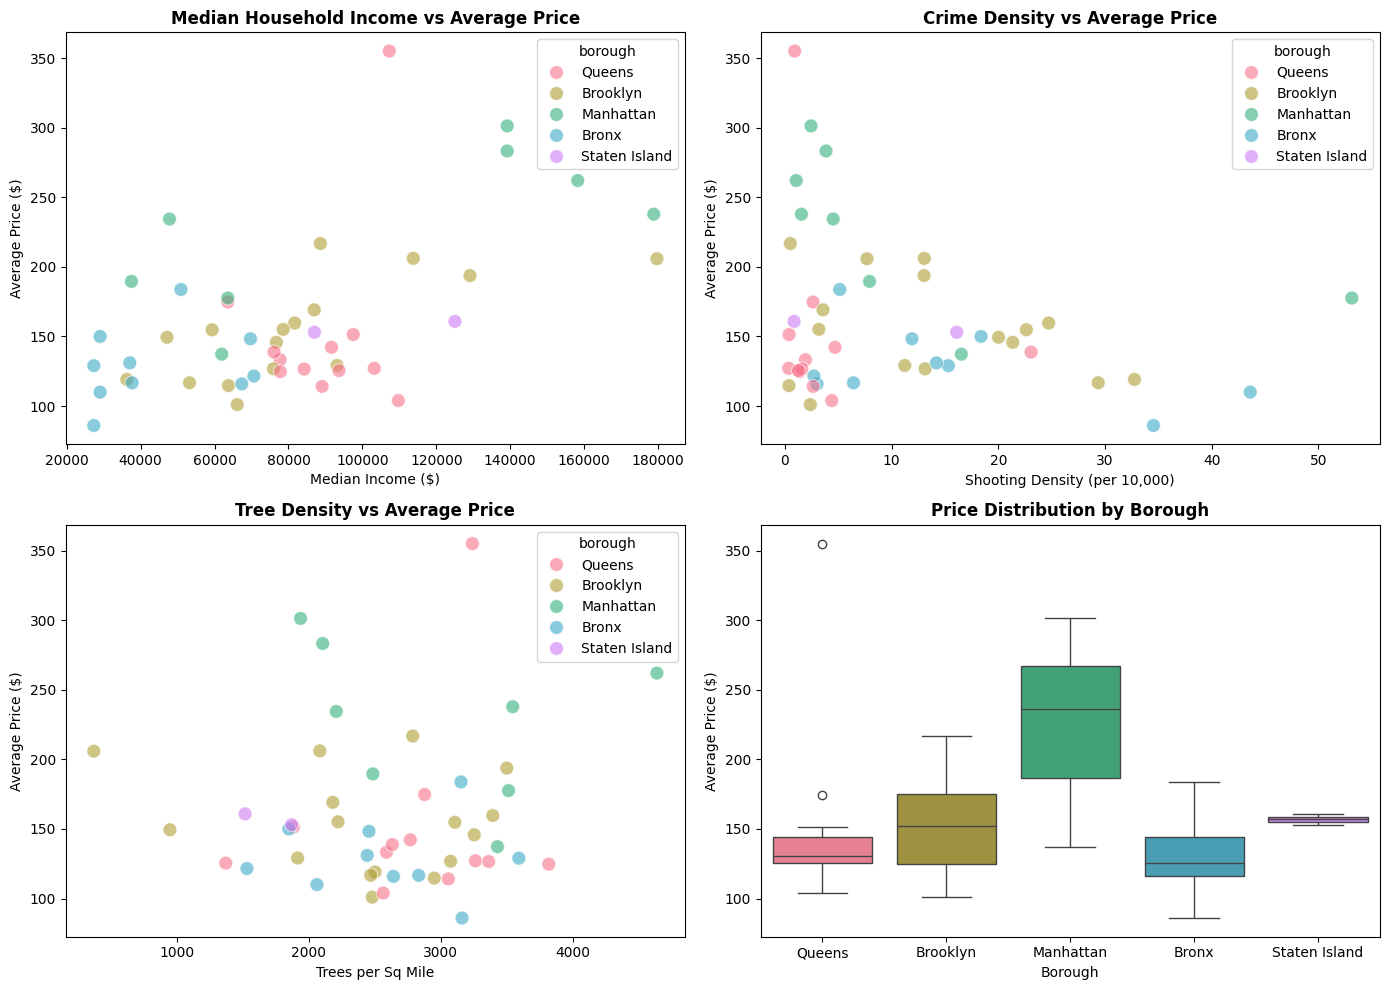

Relationship panel created showing price interactions with key features


In [61]:
# Relationship panel: Key features vs price (by borough)

# Use borough_analysis which has the borough column
analysis_subset = borough_analysis[[
    'neighbourhood',
    'borough',
    'avg_price_entire_home',
    'median_income_2019',
    'shootings_per_10000_2015_2019',
    'trees_per_sq_mile'
]].dropna()

# Create figure with subplots for key relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Income vs Price
sns.scatterplot(data=analysis_subset, x='median_income_2019', y='avg_price_entire_home', 
                hue='borough', ax=axes[0, 0], s=100, alpha=0.6, palette='husl')
axes[0, 0].set_title('Median Household Income vs Average Price', fontweight='bold')
axes[0, 0].set_xlabel('Median Income ($)')
axes[0, 0].set_ylabel('Average Price ($)')

# Crime vs Price
sns.scatterplot(data=analysis_subset, x='shootings_per_10000_2015_2019', y='avg_price_entire_home',
                hue='borough', ax=axes[0, 1], s=100, alpha=0.6, palette='husl')
axes[0, 1].set_title('Crime Density vs Average Price', fontweight='bold')
axes[0, 1].set_xlabel('Shooting Density (per 10,000)')
axes[0, 1].set_ylabel('Average Price ($)')

# Trees vs Price
sns.scatterplot(data=analysis_subset, x='trees_per_sq_mile', y='avg_price_entire_home',
                hue='borough', ax=axes[1, 0], s=100, alpha=0.6, palette='husl')
axes[1, 0].set_title('Tree Density vs Average Price', fontweight='bold')
axes[1, 0].set_xlabel('Trees per Sq Mile')
axes[1, 0].set_ylabel('Average Price ($)')

# Price distribution by borough
sns.boxplot(data=analysis_subset, x='borough', y='avg_price_entire_home', ax=axes[1, 1], palette='husl')
axes[1, 1].set_title('Price Distribution by Borough', fontweight='bold')
axes[1, 1].set_xlabel('Borough')
axes[1, 1].set_ylabel('Average Price ($)')

plt.tight_layout()
plt.show()

print('Relationship panel created showing price interactions with key features')

---

# Possible actions based on results (Act)

## Recommendations

The findings point to a few practical actions worth considering for new hosts and platforms operating in the NYC market:

1. **Pricing by location**: New hosts should benchmark against neighbourhood-level median prices and factor in their distance to Manhattan's CBD when setting initial listing prices.
2. **Safety as a differentiator**: Hosts in high-arrest / high-shooting-density neighbourhoods may need to offer more competitively low prices or invest in listing quality signals (professional photography, detailed descriptions) to offset the perceived neighbourhood risk premium.
3. **Greenery & livability**: Listings near large parks or tree-lined streets could market this as a premium feature, given the modest positive price signal.
4. **Income segmentation**: Platforms and analysts should segment NYC into income tiers when building pricing models, as median income is one of the most consistent predictors of neighbourhood-level price floors.

## Next Steps

- Extend the same R-squared-drop and ML-importance framework to time-series slices (for example 2020-2023) to test whether factor importance remains stable over time.
- Expand geographical resolution from neighbourhood-level aggregates to finer NTA-level boundaries for more localized interpretation.
- Add sentiment-derived review features and re-check whether explanatory rankings shift when quality perception is explicitly modeled.
- Compare default models against tuned versions in future work; in this project, default hyperparameters are intentionally used because tuning is outside current module scope.–2023) to test whether factor importance remains stable over time.
- Expand geographical resolution from neighbourhood-level aggregates to finer NTA-level boundaries for more localized interpretation.
- Add sentiment-derived review features and re-check whether explanatory rankings shift when quality perception is explicitly modeled.
- Compare default models against tuned versions in future work; in this project, default hyperparameters are intentionally used because tuning is outside current module scope.

---

# Final Reflection

## Limitations

- **Temporal mismatch**: The Airbnb dataset is from 2019, the tree census from 2015, and arrest/shooting data spans 2006-2019. Features derived from different years may introduce temporal inconsistencies.
- **Population baseline**: Per-capita crime rates use 2010 NTA census population figures, as neighbourhood-level estimates for 2019 were unavailable. Areas with significant population change between 2010 and 2019 may have slightly distorted crime density values.
- **Reporting bias**: Crime datasets only capture reported incidents; under-reporting in certain neighbourhoods may distort safety metrics.
- **Fuzzy matching errors**: Neighbourhood name harmonization via fuzzy matching introduces a small risk of incorrect linkages, particularly for ambiguously named areas.
- **Omitted variables**: Factors such as transit access, school quality, tourism proximity, and Airbnb amenities are not captured in this dataset and may confound results.
- **Correlation Causation**: All relationships identified are correlational; causal claims require experimental or quasi-experimental designs.

## Considerations on data ethics

- **Neighbourhood stigmatization**: Associating high crime density with lower Airbnb prices could reinforce negative stereotypes about certain communities. Results should be communicated carefully and in broader socioeconomic context.
- **Gentrification risk**: Using Airbnb pricing patterns to guide investment could accelerate gentrification in lower-income neighbourhoods that are currently underpriced.

## Considerations on data privacy and security

- All datasets used are publicly available and do not include personally identifiable information (PII) at the individual level.
- Host names and listing IDs in the Airbnb dataset could theoretically be linked to individuals; these columns are not used in any analytical outputs.
- Crime data involves sensitive demographic information; only aggregate borough/neighbourhood counts are used, with no individual-level profiling.